In [1]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\sixdo
['.cache', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.vscode', '.vscode-shared', 'analysis_outputs', 'AppData', 'Application Data', 'catboost_info', 'Contacts', 'Cookies', 'Desktop', 'Documents', 'Downloads', 'Favorites', 'Links', 'Local Settings', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TM.blf', 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'Pictures', 'PrintHood', 'Recent', 'Revised_ML.ipynb', 'Saved Games', 'Searches', 'SendTo', 'Templates', 'venv', 'Videos', '시작 메뉴']


In [2]:
# ── SECTION 1: STANDARD LIBRARY IMPORTS ─────────────────────

import os
import sys
import json
import pickle

In [3]:
%pip install numpy pandas matplotlib scipy scikit-learn xgboost catboost shap openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# ── SECTION 2: CORE SCIENTIFIC LIBRARIES ────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
# ── SECTION 3: STATISTICAL / MONTE CARLO TOOLS ──────────────

from scipy import stats   # Probability distributions for CSP sampling

In [6]:
# ── SECTION 4: SCIKIT-LEARN MODULES ─────────────────────────

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    RepeatedKFold,
    learning_curve
)
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.inspection import permutation_importance

In [7]:
# ── SECTION 5: GRADIENT BOOSTING MODELS ─────────────────────

from xgboost import XGBRegressor
from catboost import CatBoostRegressor

In [8]:
# ── SECTION 6: EXPLAINABLE AI ───────────────────────────────

import shap

C:\Users\sixdo\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
# SECTION 7: GLOBAL CONFIGURATION

RANDOM_STATE   = 42
TEST_SIZE      = 0.20
N_REPEAT_PERM  = 30
OUT            = "analysis_outputs"

os.makedirs(OUT, exist_ok=True)

In [10]:
desktop = r"C:\Users\sixdo\Desktop"
print(os.listdir(desktop))

['7103 - Chrome.lnk', 'Autodesk Fusion.lnk', 'Chrome 원격 데스크톱.lnk', 'CVLw - 바로 가기.lnk', 'desktop.ini', 'dongjun', 'Excel.lnk', 'final data', 'final data.7z', 'MDesk.lnk', 'Mesh.section.xlsx', 'ML_bond', 'ML_Revision', 'PowerPoint.lnk', 'proj.xlsx', 'SCP10 75x75', 'SCP1~9 사진.hwpx', 'stl 원본 파일', 'stl파일.zip', 'Visual Studio Code.lnk', 'Word.lnk', '경북대_콘크리트_SCP10_v1', '보성강댐', '붙임5. 3월 플립드러닝 조교 근무내역서 및 근무상황부 등(서식).xlsx', '새 폴더', '인장강도 2월 9일 23일.hwpx', '인장강도.hwpx', '학교 - Edge.lnk']


In [11]:
# SECTION 8: DATA LOADING & INITIAL CLEANING

df = pd.read_excel(r"C:\Users\sixdo\Desktop\ML_Revision\inputxlxs1.xlsx")

# Original row count
n_original = len(df)

# Drop rows with any missing values
n_missing_rows = df.isna().any(axis=1).sum()
df.dropna(inplace=True)
n_after_dropna = len(df)

# Normalise the Surface Preparation Method column
df["SSPM"] = df["SSPM"].astype(str).str.strip().str.lower()

# Coerce target column to numeric; drop rows where conversion fails
target = "BS"
n_before_bs_cleaning = len(df)

df[target] = pd.to_numeric(df[target], errors="coerce")

n_invalid_bs_rows = df[target].isna().sum()
df = df.dropna(subset=[target]).reset_index(drop=True)

# Final row count
n_final = len(df)

print("Columns:", df.columns.tolist())

print("\n── Data Cleaning Summary ─────────────────────────────")
print(f"Original rows                         : {n_original}")
print(f"Rows dropped due to missing values    : {n_missing_rows}")
print(f"Rows after missing-value removal      : {n_after_dropna}")
print(f"Rows dropped due to invalid BS values : {n_invalid_bs_rows}")
print(f"Final rows used for analysis          : {n_final}")
print(f"Total rows dropped                    : {n_original - n_final}")
print(f"Total drop percentage                 : {(n_original - n_final) / n_original * 100:.2f}%")

Columns: ['BTT', 'SSPM', 'SCA', 'SA', 'BA', 'RMT', 'RCA', 'RMA', 'w/c_S', 'w/c_R', 'fc_S', 'fc_R', 'Gmax', 'Barea', 'BS']

── Data Cleaning Summary ─────────────────────────────
Original rows                         : 1313
Rows dropped due to missing values    : 0
Rows after missing-value removal      : 1313
Rows dropped due to invalid BS values : 0
Final rows used for analysis          : 1313
Total rows dropped                    : 0
Total drop percentage                 : 0.00%


In [12]:
# SECTION 9: SSPM VALIDATION & FILTERING

# Curated whitelist of accepted surface preparation methods
CURATED_SSPM = [
    "acid etching", "brushing", "chemical treatment", "chipping",
    "grinding", "grit blasting", "grooving", "grooving + acid etching",
    "grooving + wire brushing", "high roughness",
    "high roughness + drilling", "high roughness + grooving",
    "hole drilling", "jack hammering", "jack hammering + sand blasting",
    "keyway", "left as cast", "low roughness", "milling",
    "polishing", "sand blasting", "scarification",
    "shot blasting", "smooth", "water jetting", "wire brushing",
]
CURATED_SSPM = [x.strip().lower() for x in CURATED_SSPM]

# Correct known misspellings before validation

SSPM_CORRECTIONS = {
    "acid ecthing": "acid etching",
}

df["SSPM_original"] = df["SSPM"]   # keep original value for checking
df["SSPM"] = df["SSPM"].replace(SSPM_CORRECTIONS)

# Report corrected SSPM values
corrected_rows = df[df["SSPM_original"] != df["SSPM"]]

print(f"Rows corrected (SSPM spelling): {len(corrected_rows)}")

if len(corrected_rows) > 0:
    print("Corrections made:")
    print(
        corrected_rows[["SSPM_original", "SSPM"]]
        .drop_duplicates()
        .to_string(index=False)
    )

# Report and remove only still-invalid SSPM entries

invalid_rows = df[~df["SSPM"].isin(CURATED_SSPM)]

print(f"\nRows removed (invalid SSPM): {len(invalid_rows)}")

if len(invalid_rows) > 0:
    print("Invalid values found:", invalid_rows["SSPM"].unique())
else:
    print("Invalid values found: None")

df = df[df["SSPM"].isin(CURATED_SSPM)].copy()

# Remove helper column after validation
df.drop(columns=["SSPM_original"], inplace=True)

print("\nRemaining unique SSPM values:", sorted(df["SSPM"].unique()))

Rows corrected (SSPM spelling): 9
Corrections made:
SSPM_original         SSPM
 acid ecthing acid etching

Rows removed (invalid SSPM): 0
Invalid values found: None

Remaining unique SSPM values: ['acid etching', 'brushing', 'chemical treatment', 'chipping', 'grinding', 'grit blasting', 'grooving', 'grooving + acid etching', 'grooving + wire brushing', 'high roughness', 'high roughness + drilling', 'high roughness + grooving', 'hole drilling', 'jack hammering', 'jack hammering + sand blasting', 'keyway', 'left as cast', 'low roughness', 'milling', 'polishing', 'sand blasting', 'scarification', 'shot blasting', 'smooth', 'water jetting', 'wire brushing']


In [13]:
# SECTION 9B: FEATURE ENGINEERING

# ── 9B-A: CSP (Concrete Surface Profile) Lookup ──────────────
#
#  Each method maps to a (min, max) CSP range per ICRI guidelines.
#  Used later to derive a triangular distribution for Monte Carlo.

CSP_MAP = {
    "smooth":                         (1, 2),
    "left as cast":                   (1, 2),
    "polishing":                      (1, 1),
    "acid etching":                   (1, 2),
    "chemical treatment":             (1, 2),
    "grinding":                       (2, 3),
    "brushing":                       (2, 4),
    "wire brushing":                  (2, 3),
    "water jetting":                  (3, 6),
    "sand blasting":                  (3, 6),
    "shot blasting":                  (3, 7),
    "grit blasting":                  (4, 6),
    "scarification":                  (4, 7),
    "milling":                        (5, 8),
    "grooving":                       (5, 8),
    "grooving + acid etching":        (5, 7),
    "grooving + wire brushing":       (5, 7),
    "chipping":                       (6, 8),
    "keyway":                         (6, 8),
    "hole drilling":                  (7, 9),
    "jack hammering":                 (7, 9),
    "jack hammering + sand blasting": (7, 10),
    "low roughness":                  (2, 4),
    "high roughness":                 (7, 9),
    "high roughness + grooving":      (8, 10),
    "high roughness + drilling":      (9, 10),
}

# ── 9B-B: Microcrack Severity Lookup ─────────────────────────
#
#  Scale:  1 = negligible  |  2 = moderate  |  3 = significant

MICRO_MAP = {
    "smooth":                         1,
    "left as cast":                   1,
    "acid etching":                   1,
    "chemical treatment":             1,
    "grinding":                       2,
    "brushing":                       1,
    "wire brushing":                  1,
    "water jetting":                  2,
    "sand blasting":                  2,
    "shot blasting":                  2,
    "grit blasting":                  2,
    "scarification":                  2,
    "milling":                        3,
    "grooving":                       3,
    "grooving + acid etching":        2,
    "grooving + wire brushing":       2,
    "chipping":                       3,
    "keyway":                         3,
    "hole drilling":                  3,
    "jack hammering":                 3,
    "jack hammering + sand blasting": 3,
    "low roughness":                  1,
    "high roughness":                 3,
    "high roughness + grooving":      3,
    "high roughness + drilling":      3,
}

# ── 9B-C: Apply Mappings ──────────────────────────────────────

def _map_csp(sspm_value):
    """Return (CSP_min, CSP_max) tuple for a given SSPM string."""
    return CSP_MAP.get(sspm_value, (np.nan, np.nan))

df[["CSP_min", "CSP_max"]] = df["SSPM"].apply(
    lambda x: pd.Series(_map_csp(x))
)
df["Microcrack"] = df["SSPM"].map(MICRO_MAP)

# Report unmapped rows
missing_csp = df["CSP_min"].isna().sum()
print(f"Missing CSP mappings (filled with median): {missing_csp}")

# Robust fallback: fill any gaps with column medians
df["CSP_min"]    = df["CSP_min"].fillna(df["CSP_min"].median())
df["CSP_max"]    = df["CSP_max"].fillna(df["CSP_max"].median())
df["Microcrack"] = df["Microcrack"].fillna(df["Microcrack"].median())

# Midpoint used as the triangular distribution mode
df["CSP_mean"] = (df["CSP_min"] + df["CSP_max"]) / 2

print("Columns after feature engineering:", df.columns.tolist())

Missing CSP mappings (filled with median): 0
Columns after feature engineering: ['BTT', 'SSPM', 'SCA', 'SA', 'BA', 'RMT', 'RCA', 'RMA', 'w/c_S', 'w/c_R', 'fc_S', 'fc_R', 'Gmax', 'Barea', 'BS', 'CSP_min', 'CSP_max', 'Microcrack', 'CSP_mean']


In [14]:
print(os.getcwd())
print(os.listdir("analysis_outputs"))

C:\Users\sixdo
['EDA_categorical_distributions.png', 'EDA_counts_BA.csv', 'EDA_counts_BTT.csv', 'EDA_counts_RMT.csv', 'EDA_numerical_summary.csv', 'EDA_numerical_summary_with_BS.csv', 'EDA_numeric_distributions.png', 'EDA_numeric_distributions_with_BS.png', 'EDA_spearman_categorical_encoding.txt', 'EDA_spearman_correlation_heatmap.png', 'EDA_spearman_correlation_matrix.csv', 'MC_diagnostics.png']


In [15]:
# ============================================================
# Plot styling helper functions
# Put this BEFORE plot_monte_carlo_diagnostics()
# ============================================================

def _style_ax(ax, title, xlabel, ylabel):
    """Apply uniform plot styling to a matplotlib Axes object."""
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel(xlabel, fontsize=12, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=12, fontweight="bold")
    ax.tick_params(axis="both", which="major", labelsize=11)

    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontweight("bold")

    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

    ax.grid(False)


def _save_show(fig, path):
    """Save figure, show it, then close cleanly."""
    if path:
        fig.savefig(path, dpi=300, bbox_inches="tight", facecolor="white")
        print(f"Saved → {path}")

    plt.show()
    plt.close(fig)


── Monte Carlo Simulation ──────────────────────────────
  Iter    0 | Mean CSP: 3.9194
  Iter    1 | Mean CSP: 3.9285
  Iter    2 | Mean CSP: 3.9120
  Iter    3 | Mean CSP: 3.9416
  Iter    4 | Mean CSP: 3.8993
  Iter    5 | Mean CSP: 3.9242
  Iter    6 | Mean CSP: 3.9183
  Iter    7 | Mean CSP: 3.8928
  Iter    8 | Mean CSP: 3.9421
  Iter    9 | Mean CSP: 3.8998
  Iter   10 | Mean CSP: 3.9252
  Iter   11 | Mean CSP: 3.9257
  Iter   12 | Mean CSP: 3.9173
  Iter   13 | Mean CSP: 3.9132
  Iter   14 | Mean CSP: 3.9240
  Iter   15 | Mean CSP: 3.9356
  Iter   16 | Mean CSP: 3.9419
  Iter   17 | Mean CSP: 3.9219
  Iter   18 | Mean CSP: 3.9170
  Iter   19 | Mean CSP: 3.9185
  Iter   20 | Mean CSP: 3.9178
  Iter   21 | Mean CSP: 3.9140
  Iter   22 | Mean CSP: 3.9110
  Iter   23 | Mean CSP: 3.9001
  Iter   24 | Mean CSP: 3.9228
  Iter   25 | Mean CSP: 3.9262
  Iter   26 | Mean CSP: 3.9260
  Iter   27 | Mean CSP: 3.9069
  Iter   28 | Mean CSP: 3.9056
  Iter   29 | Mean CSP: 3.9297
  Iter   30 

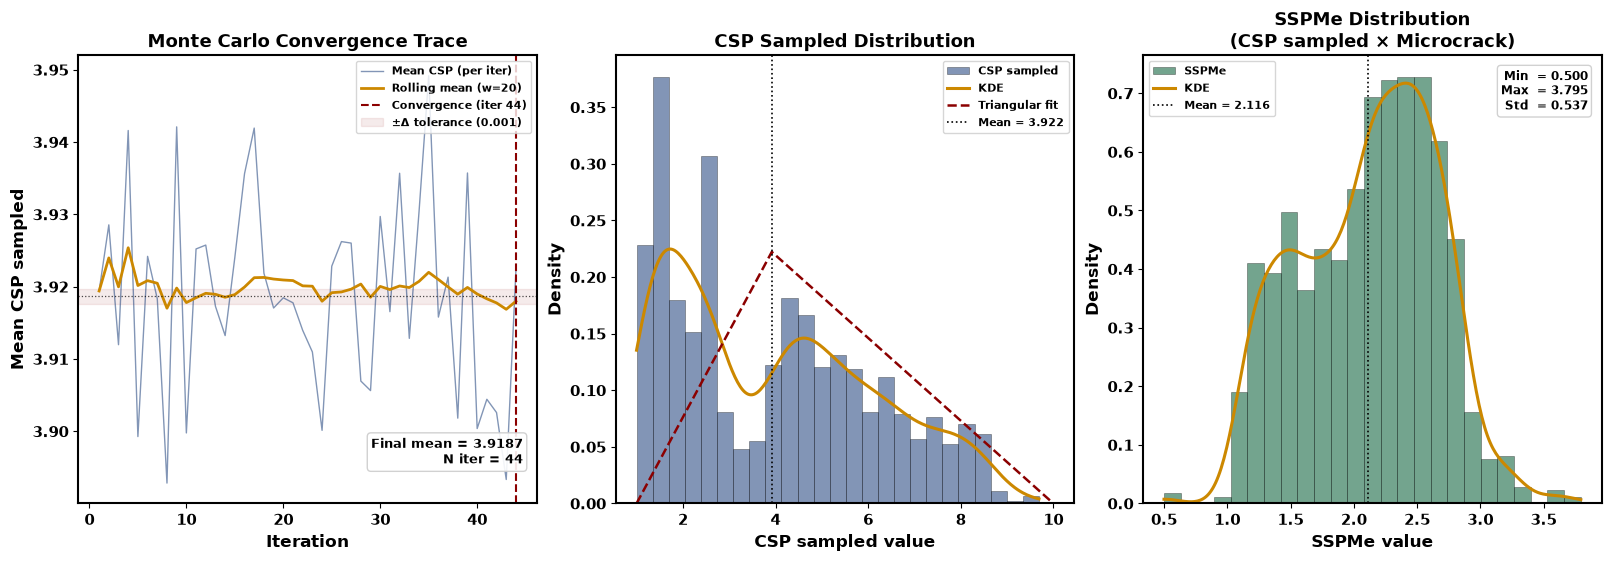

In [16]:
# SECTION 10: MONTE CARLO CSP SIMULATION & DIAGNOSTICS

#  10A  Triangular sampling function
#  10B  Convergence loop (max 500 iterations, tol = 1e-3)
#  10C  SSPMe composite feature (CSP_sampled × Microcrack)
#  10D  Diagnostic plot function
#  10E  Call: convergence trace, CSP distribution, SSPMe dist.
#
#  The simulation samples CSP from triangular(CSP_min,
#  CSP_mean, CSP_max) for each row until the rolling-window
#  mean stabilises.  Diagnostic plots are produced immediately
#  after convergence so all Monte Carlo outputs are co-located.
#
#  Saved to: analysis_outputs/MC_diagnostics.png


def _sample_csp_triangular(row):
    """
    Draw one CSP sample from a triangular distribution.
    Falls back to a deterministic value when min == max.
    """
    lo, mode, hi = row["CSP_min"], row["CSP_mean"], row["CSP_max"]
    if lo == hi:
        return lo
    return np.random.triangular(lo, mode, hi)


N_SIM       = 500   # Maximum iterations
CONV_WINDOW = 20    # Rolling window size for convergence check
CONV_TOL    = 1e-3  # Convergence tolerance (Δ between windows)

csp_means = []

print("\n── Monte Carlo Simulation ──────────────────────────────")
for i in range(N_SIM):

    df["CSP_sampled"] = df.apply(_sample_csp_triangular, axis=1)
    current_mean = df["CSP_sampled"].mean()
    csp_means.append(current_mean)

    if i >= 2 * CONV_WINDOW:
        recent   = np.mean(csp_means[-CONV_WINDOW:])
        previous = np.mean(csp_means[-2 * CONV_WINDOW:-CONV_WINDOW])
        delta    = abs(recent - previous)
        print(f"  Iter {i:>4d} | Mean CSP: {current_mean:.4f} | Δ: {delta:.6f}")
        if delta < CONV_TOL:
            print(f"\n  ✅ Converged at iteration {i}")
            break
    else:
        print(f"  Iter {i:>4d} | Mean CSP: {current_mean:.4f}")

print("\n── Monte Carlo Summary ─────────────────────────────────")
print(f"  Total iterations : {len(csp_means)}")
print(f"  Final mean CSP   : {np.mean(csp_means):.4f}")

# Composite surface-effect feature: roughness × microcrack severity
df["SSPMe"] = df["CSP_sampled"] / df["Microcrack"]

print("\nSSPMe preview:")
print(df[["CSP_sampled", "Microcrack", "SSPMe"]].head())
print(df["SSPMe"].describe())

# ============================================================

def plot_monte_carlo_diagnostics(csp_means, df,
                                 conv_window, conv_tol,
                                 save_path=None):
    """
    Three-panel Monte Carlo diagnostic figure.

    Parameters
    ----------
    csp_means   : list[float] — mean CSP recorded at each iteration
    df          : pd.DataFrame — final dataframe (post-convergence)
                  must contain columns CSP_sampled and SSPMe
    conv_window : int  — rolling window used for convergence check
    conv_tol    : float — convergence tolerance Δ
    save_path   : str | None — output file path
    """
    from scipy.stats import gaussian_kde

    n_iter        = len(csp_means)
    iterations    = np.arange(1, n_iter + 1)
    means_arr     = np.array(csp_means)
    final_mean    = means_arr.mean()

    # Locate convergence point (first iter where rolling Δ < tol)
    conv_iter = n_iter  # default: never converged (shouldn't happen)
    for i in range(2 * conv_window, n_iter):
        recent   = np.mean(means_arr[i - conv_window: i])
        previous = np.mean(means_arr[i - 2*conv_window: i - conv_window])
        if abs(recent - previous) < conv_tol:
            conv_iter = i + 1   # 1-indexed
            break

    # Rolling mean for smoothed trace
    roll_mean = pd.Series(means_arr).rolling(conv_window,
                          min_periods=1).mean().values

    # ── Figure layout: 1 row × 3 panels ──────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(16, 5.5),
                             constrained_layout=True)

    # ── Panel A: Convergence trace ────────────────────────────
    ax = axes[0]

    ax.plot(iterations, means_arr,
            color="#1b3f7a", linewidth=1.0,
            alpha=0.55, label="Mean CSP (per iter)")
    ax.plot(iterations, roll_mean,
            color="#cc8800", linewidth=2.0,
            label=f"Rolling mean (w={conv_window})")

    # Convergence vertical line
    ax.axvline(conv_iter, color="#8b0000", linewidth=1.5,
               linestyle="--",
               label=f"Convergence (iter {conv_iter})")

    # Final mean ± tolerance band
    ax.axhline(final_mean, color="black", linewidth=0.9,
               linestyle=":", alpha=0.7)
    ax.axhspan(final_mean - conv_tol,
               final_mean + conv_tol,
               color="#8b0000", alpha=0.08,
               label=f"±Δ tolerance ({conv_tol})")

    _style_ax(ax,
              title  = "Monte Carlo Convergence Trace",
              xlabel = "Iteration",
              ylabel = "Mean CSP sampled")
    ax.legend(fontsize=8, prop={"weight": "bold", "size": 8},
              loc="upper right")

    # Annotate final mean value
    ax.text(0.97, 0.08,
            f"Final mean = {final_mean:.4f}\nN iter = {n_iter}",
            transform=ax.transAxes, ha="right", va="bottom",
            fontsize=9, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3",
                      fc="white", ec="#cccccc", alpha=0.9))

    # ── Panel B: CSP_sampled distribution ────────────────────
    ax = axes[1]

    csp_vals = df["CSP_sampled"].dropna().values

    ax.hist(csp_vals, bins=25, density=True,
            color="#1b3f7a", alpha=0.55,
            edgecolor="black", linewidth=0.4,
            label="CSP sampled")

    # KDE overlay
    if len(csp_vals) > 3:
        kde_x = np.linspace(csp_vals.min(), csp_vals.max(), 300)
        kde   = gaussian_kde(csp_vals, bw_method="scott")
        ax.plot(kde_x, kde(kde_x),
                color="#cc8800", linewidth=2.2,
                label="KDE")

    # Fitted triangular overlay using dataset-level min/mean/max
    tri_lo   = df["CSP_min"].min()
    tri_hi   = df["CSP_max"].max()
    tri_mode = df["CSP_mean"].mean()

    if tri_hi > tri_lo:
        from scipy.stats import triang
        c_param  = (tri_mode - tri_lo) / (tri_hi - tri_lo)
        tri_x    = np.linspace(tri_lo, tri_hi, 300)
        tri_pdf  = triang.pdf(tri_x, c_param,
                              loc=tri_lo, scale=tri_hi - tri_lo)
        ax.plot(tri_x, tri_pdf,
                color="#8b0000", linewidth=1.8,
                linestyle="--", label="Triangular fit")

    ax.axvline(csp_vals.mean(), color="black",
               linewidth=1.2, linestyle=":",
               label=f"Mean = {csp_vals.mean():.3f}")

    _style_ax(ax,
              title  = "CSP Sampled Distribution",
              xlabel = "CSP sampled value",
              ylabel = "Density")
    ax.legend(fontsize=8, prop={"weight": "bold", "size": 8})

    # ── Panel C: SSPMe distribution ───────────────────────────
    ax = axes[2]

    sspme_vals = df["SSPMe"].dropna().values

    ax.hist(sspme_vals, bins=25, density=True,
            color="#005a32", alpha=0.55,
            edgecolor="black", linewidth=0.4,
            label="SSPMe")

    # KDE overlay
    if len(sspme_vals) > 3:
        kde_x2 = np.linspace(sspme_vals.min(), sspme_vals.max(), 300)
        kde2   = gaussian_kde(sspme_vals, bw_method="scott")
        ax.plot(kde_x2, kde2(kde_x2),
                color="#cc8800", linewidth=2.2,
                label="KDE")

    ax.axvline(sspme_vals.mean(), color="black",
               linewidth=1.2, linestyle=":",
               label=f"Mean = {sspme_vals.mean():.3f}")

    ax.text(0.97, 0.97,
            f"Min  = {sspme_vals.min():.3f}\n"
            f"Max  = {sspme_vals.max():.3f}\n"
            f"Std  = {sspme_vals.std():.3f}",
            transform=ax.transAxes, ha="right", va="top",
            fontsize=8.5, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3",
                      fc="white", ec="#cccccc", alpha=0.9))

    _style_ax(ax,
              title  = "SSPMe Distribution\n(CSP sampled × Microcrack)",
              xlabel = "SSPMe value",
              ylabel = "Density")
    ax.legend(fontsize=8, prop={"weight": "bold", "size": 8})

    _save_show(fig, save_path)


# ── Call ──────────────────────────────────────────────────────

plot_monte_carlo_diagnostics(
    csp_means   = csp_means,
    df          = df,
    conv_window = CONV_WINDOW,
    conv_tol    = CONV_TOL,
    save_path   = os.path.join(OUT, "MC_diagnostics.png"),
)

In [17]:
# SECTION 11: FEATURE MATRIX CONSTRUCTION
# ============================================================

# Drop columns not used as model inputs
DROP_COLS = ["BS", "SSPM", "SCA", "w/c_S", "RCA", "CSP_min", "CSP_max", "CSP_sampled", "CSP_mean", "Microcrack"]

y = df["BS"]
X = df.drop(columns=DROP_COLS)

print("\nFeature columns:", X.columns.tolist())
print(f"X shape: {X.shape}  |  y shape: {y.shape}")

# ── 12A: Train / Test Split (raw, for CatBoost) ─────────────

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

# Identify categorical vs numerical columns
CATEGORICAL_COLS = ["BTT", "BA", "RMT"]
NUMERICAL_COLS   = [c for c in X.columns if c not in CATEGORICAL_COLS]

# ── 12B: Encoded Feature Matrix (for tree / XGB models) ─────

X_encoded = X.copy()

# Binary-encode BA
if "BA" in X_encoded.columns:
    X_encoded["BA"] = X_encoded["BA"].map({"Yes": 1, "No": 0})
else:
    print("WARNING: 'BA' column not found — skipping binary encoding")

# One-hot encode remaining categoricals
ohe_cols = [c for c in ["RMT", "BTT"] if c in X_encoded.columns]
X_encoded = pd.get_dummies(X_encoded, columns=ohe_cols, drop_first=True)

print(f"\nEncoded feature matrix shape: {X_encoded.shape}")

# Encoded train / test split
X_train_enc, X_test_enc, y_train, y_test = train_test_split(
    X_encoded, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

# Align columns to guard against OHE mismatch
X_train_enc, X_test_enc = X_train_enc.align(
    X_test_enc, join="left", axis=1, fill_value=0
)



Feature columns: ['BTT', 'SA', 'BA', 'RMT', 'RMA', 'w/c_R', 'fc_S', 'fc_R', 'Gmax', 'Barea', 'SSPMe']
X shape: (1313, 11)  |  y shape: (1313,)

Encoded feature matrix shape: (1313, 24)



── Retained Feature Overview Including BS ──────────────
Numerical columns   : 9
['SA', 'RMA', 'w/c_R', 'fc_S', 'fc_R', 'Gmax', 'Barea', 'SSPMe', 'BS']

Categorical columns : 3
['BTT', 'BA', 'RMT']

── Numerical Summary Including BS ─────────────────────
        count          mean           std          min          25%  \
SA     1313.0     96.689261     54.949029    16.000000    60.000000   
RMA    1313.0     36.837268     46.292122     0.083333     9.000000   
w/c_R  1313.0      0.306346      0.148911     0.120000     0.170000   
fc_S   1313.0     45.643001     11.676435    26.050000    36.420000   
fc_R   1313.0     85.174196     53.345220    19.700000    42.400000   
Gmax   1313.0     14.916352      4.966813     6.350000    12.500000   
Barea  1313.0  12707.923269  12532.702858  1590.431281  4417.864669   
SSPMe  1313.0      2.115658      0.536771     0.500000     1.692758   
BS     1313.0      7.724321      8.622197     0.000000     1.940000   

               50%           75% 

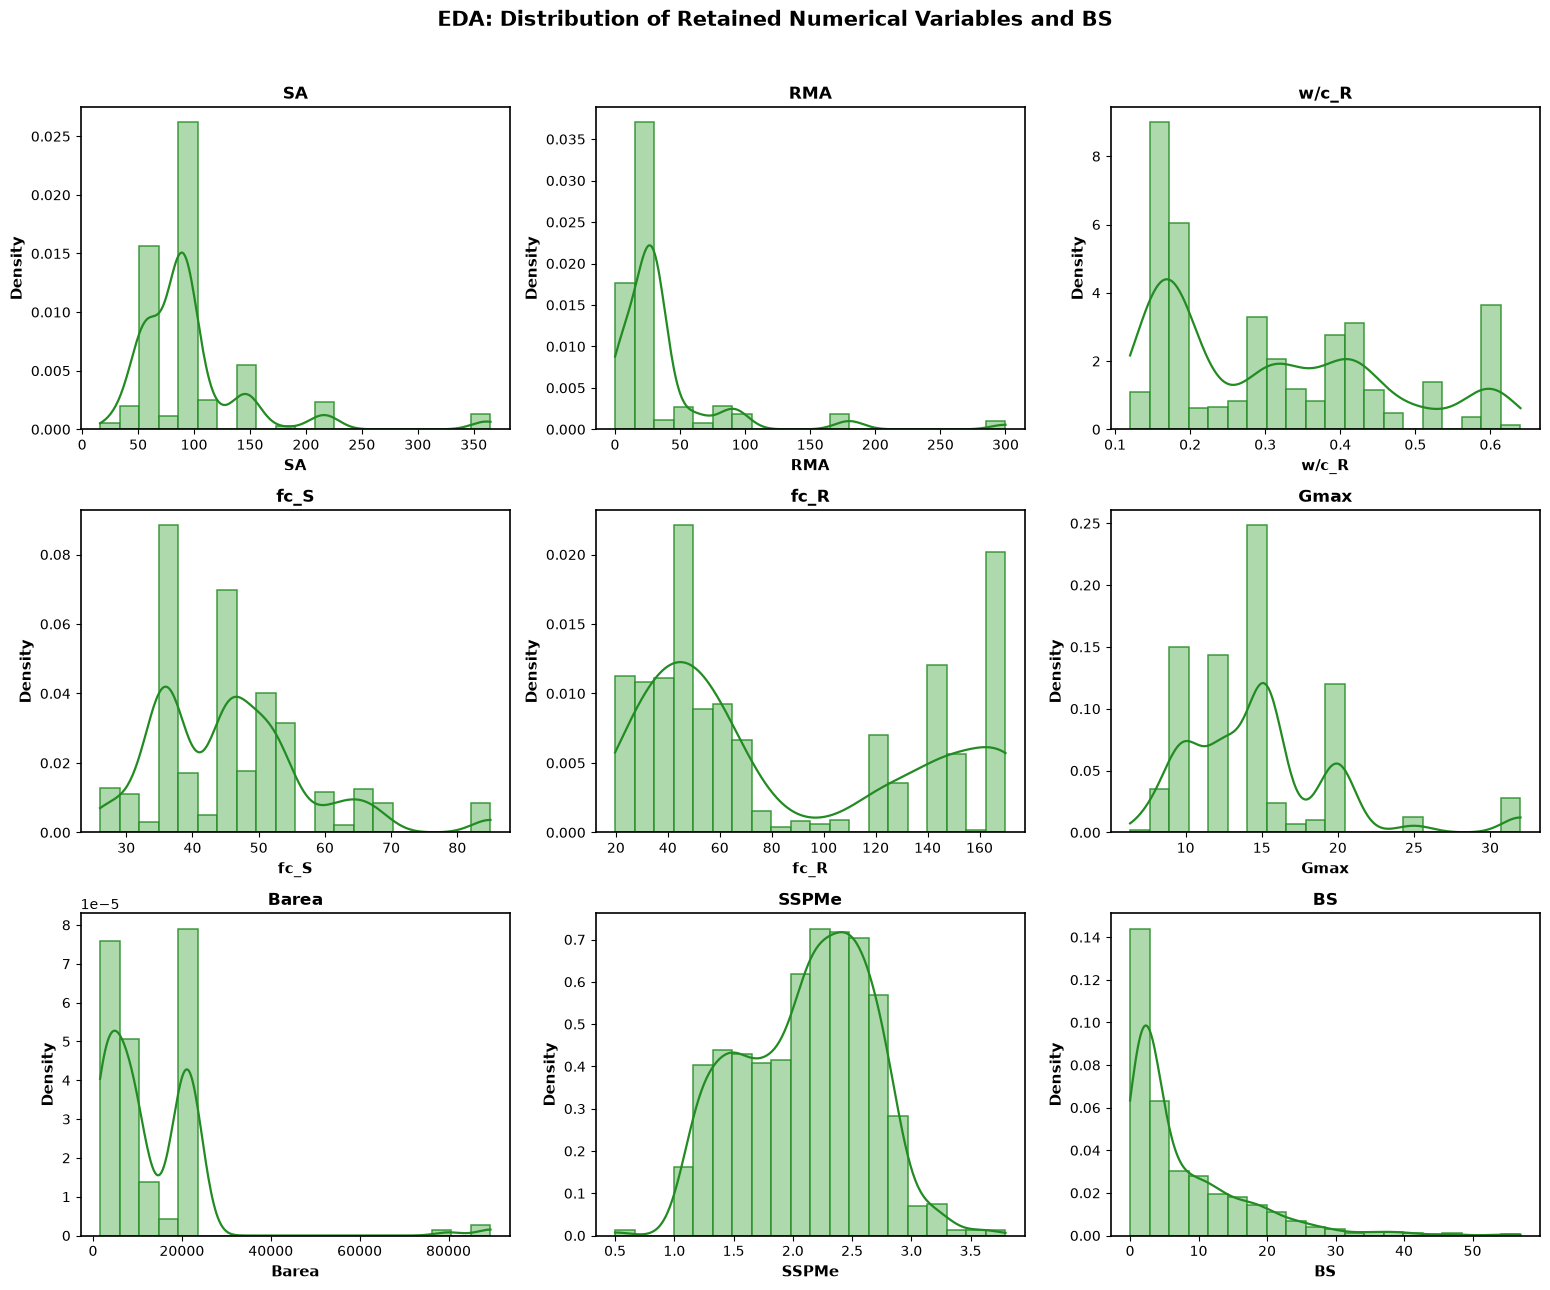


── Categorical Frequency Tables ───────────────────────

[BTT]
   BTT  count    percent
0   SS    517  39.375476
1   PO    337  25.666413
2   ST    250  19.040366
3  BSS    150  11.424219
4   DT     24   1.827875
5  3PF     18   1.370906
6   DS      6   0.456969
7  3PB      6   0.456969
8  IDT      5   0.380807
Saved → analysis_outputs\EDA_counts_BTT.csv

[BA]
    BA  count    percent
0   No    991  75.476009
1  Yes    246  18.735720
2   no     76   5.788271
Saved → analysis_outputs\EDA_counts_BA.csv

[RMT]
      RMT  count    percent
0    UHPC    418  31.835491
1     CON    390  29.702970
2     CBM    133  10.129474
3     GPM    112   8.530084
4     FRM     89   6.778370
5     PMM     59   4.493526
6     ECC     58   4.417365
7  UHPFRC     54   4.112719
Saved → analysis_outputs\EDA_counts_RMT.csv
Saved → analysis_outputs\EDA_categorical_distributions.png


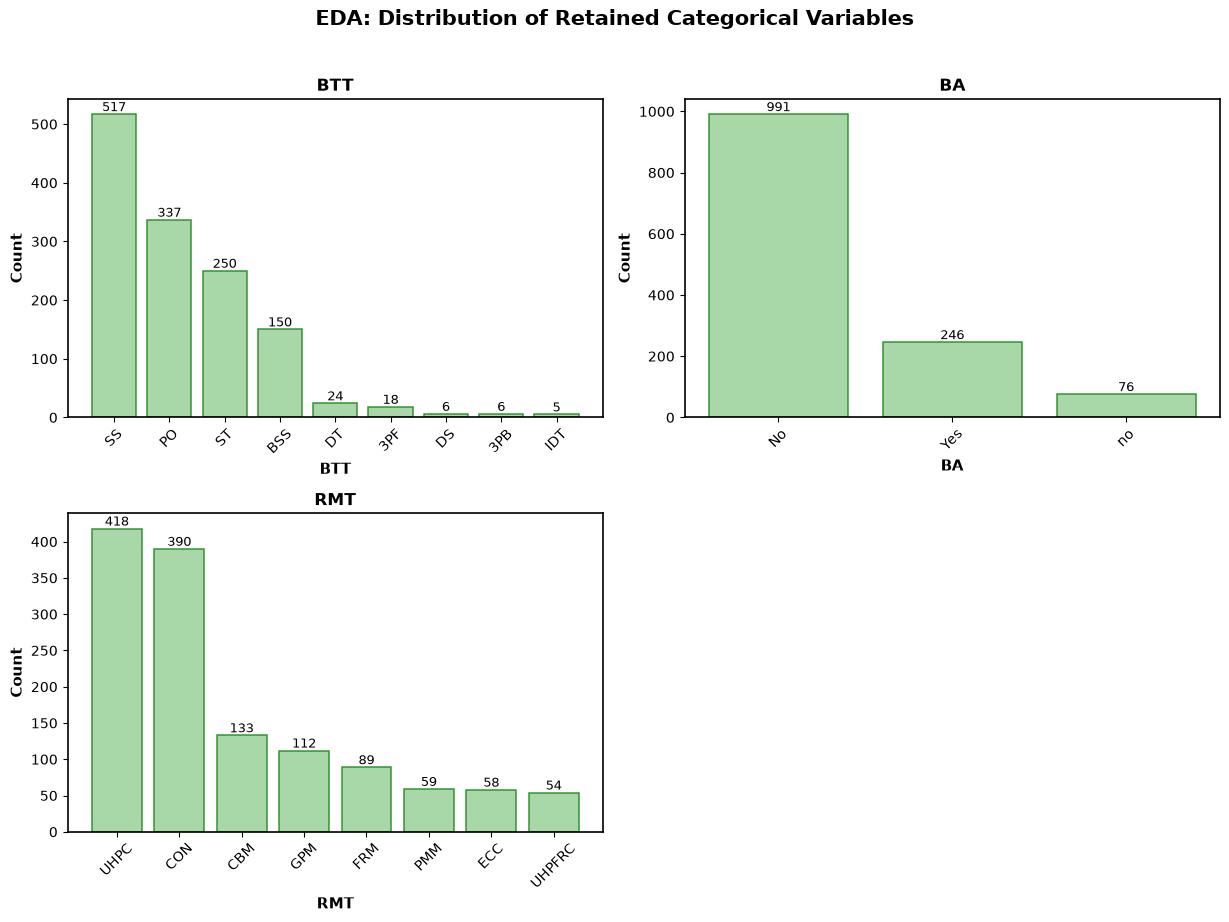

In [18]:
# SECTION 11A: EDA FOR RETAINED FEATURES + TARGET BS

import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Output folder
if "OUT" not in globals():
    OUT = "analysis_outputs"
os.makedirs(OUT, exist_ok=True)

# ------------------------------------------------------------
# Build EDA dataframe
# Retained model features + target variable BS
# ------------------------------------------------------------
eda_df = X.copy()
eda_df["BS"] = y.values

# ------------------------------------------------------------
# Identify retained numerical and categorical columns
# ------------------------------------------------------------
retained_num_cols = eda_df.select_dtypes(include=[np.number]).columns.tolist()

# Prefer user-defined categorical list if already available
if "CATEGORICAL_COLS" in globals():
    retained_cat_cols = [c for c in CATEGORICAL_COLS if c in eda_df.columns]
else:
    retained_cat_cols = eda_df.select_dtypes(include=["object", "category", "bool", "string"]).columns.tolist()

print("\n── Retained Feature Overview Including BS ──────────────")
print(f"Numerical columns   : {len(retained_num_cols)}")
print(retained_num_cols)
print(f"\nCategorical columns : {len(retained_cat_cols)}")
print(retained_cat_cols)

# ------------------------------------------------------------
# Helper: style axis
# ------------------------------------------------------------
def _eda_style_ax(ax, title, xlabel="", ylabel="Density"):
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel(xlabel, fontsize=11, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=11, fontweight="bold")
    ax.tick_params(axis="both", labelsize=10)
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

# ------------------------------------------------------------
# 11A-1: Numerical summary table
# ------------------------------------------------------------
if retained_num_cols:
    num_summary = eda_df[retained_num_cols].describe().T
    num_summary["missing"] = eda_df[retained_num_cols].isna().sum()
    num_summary["missing_%"] = 100 * num_summary["missing"] / len(eda_df)
    num_summary["skew"] = eda_df[retained_num_cols].skew(numeric_only=True)
    num_summary["kurtosis"] = eda_df[retained_num_cols].kurtosis(numeric_only=True)

    print("\n── Numerical Summary Including BS ─────────────────────")
    print(num_summary)

    num_summary.to_csv(os.path.join(OUT, "EDA_numerical_summary_with_BS.csv"))
    print(f"\nSaved → {os.path.join(OUT, 'EDA_numerical_summary_with_BS.csv')}")

# ------------------------------------------------------------
# 11A-2: Plot numerical distributions (hist + KDE)
# ------------------------------------------------------------
def plot_numeric_distributions(data, cols, save_path=None, ncols=3):
    if len(cols) == 0:
        print("No numerical columns found for EDA.")
        return

    n_plots = len(cols)
    nrows = math.ceil(n_plots / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 4.2 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, col in zip(axes, cols):
        vals = pd.to_numeric(data[col], errors="coerce").dropna().values

        if len(vals) == 0:
            ax.set_visible(False)
            continue

        # Histogram
        bins = min(20, max(8, int(np.sqrt(len(vals)))))
        ax.hist(
            vals,
            bins=bins,
            density=True,
            color="#9fd39f",
            edgecolor="forestgreen",
            linewidth=1.1,
            alpha=0.85,
        )

        # KDE overlay
        if len(np.unique(vals)) > 3:
            try:
                kde_x = np.linspace(vals.min(), vals.max(), 300)
                kde = gaussian_kde(vals)
                ax.plot(kde_x, kde(kde_x), color="forestgreen", linewidth=1.6)
            except Exception:
                pass

        _eda_style_ax(ax, title=col, xlabel=col, ylabel="Density")

    # Hide unused axes
    for ax in axes[n_plots:]:
        ax.set_visible(False)

    fig.suptitle(
        "EDA: Distribution of Retained Numerical Variables and BS",
        fontsize=15,
        fontweight="bold",
        y=1.02
    )

    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")
        print(f"Saved → {save_path}")

    plt.show()
    plt.close(fig)


plot_numeric_distributions(
    data=eda_df,
    cols=retained_num_cols,
    save_path=os.path.join(OUT, "EDA_numeric_distributions_with_BS.png"),
    ncols=3,
)

# ------------------------------------------------------------
# 11A-3: Categorical summary tables
# ------------------------------------------------------------
if retained_cat_cols:
    print("\n── Categorical Frequency Tables ───────────────────────")

    for col in retained_cat_cols:
        freq = (
            eda_df[col]
            .astype(str)
            .fillna("Missing")
            .value_counts(dropna=False)
            .rename_axis(col)
            .reset_index(name="count")
        )
        freq["percent"] = 100 * freq["count"] / freq["count"].sum()

        print(f"\n[{col}]")
        print(freq)

        freq.to_csv(os.path.join(OUT, f"EDA_counts_{col}.csv"), index=False)
        print(f"Saved → {os.path.join(OUT, f'EDA_counts_{col}.csv')}")

# ------------------------------------------------------------
# 11A-4: Plot categorical distributions (bar charts)
# ------------------------------------------------------------
def plot_categorical_distributions(data, cols, save_path=None, ncols=2):
    if len(cols) == 0:
        print("No categorical columns found for EDA.")
        return

    n_plots = len(cols)
    nrows = math.ceil(n_plots / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(6.2 * ncols, 4.5 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, col in zip(axes, cols):
        counts = data[col].astype(str).fillna("Missing").value_counts(dropna=False)

        ax.bar(
            counts.index,
            counts.values,
            color="#9fd39f",
            edgecolor="forestgreen",
            linewidth=1.1,
            alpha=0.9,
        )

        _eda_style_ax(ax, title=col, xlabel=col, ylabel="Count")
        ax.tick_params(axis="x", rotation=45)

        # Annotate counts on bars
        for i, v in enumerate(counts.values):
            ax.text(i, v, str(v), ha="center", va="bottom", fontsize=9)

    # Hide unused axes
    for ax in axes[n_plots:]:
        ax.set_visible(False)

    fig.suptitle(
        "EDA: Distribution of Retained Categorical Variables",
        fontsize=15,
        fontweight="bold",
        y=1.02
    )

    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")
        print(f"Saved → {save_path}")

    plt.show()
    plt.close(fig)


plot_categorical_distributions(
    data=eda_df,
    cols=retained_cat_cols,
    save_path=os.path.join(OUT, "EDA_categorical_distributions.png"),
    ncols=2,
)


── Categorical Encoding Used for Spearman ─────────────

[BTT]
  3PB -> 0
  3PF -> 1
  BSS -> 2
  DS -> 3
  DT -> 4
  IDT -> 5
  PO -> 6
  SS -> 7
  ST -> 8

[BA]
  No -> 0
  Yes -> 1
  no -> 2

[RMT]
  CBM -> 0
  CON -> 1
  ECC -> 2
  FRM -> 3
  GPM -> 4
  PMM -> 5
  UHPC -> 6
  UHPFRC -> 7

Saved categorical encoding map → analysis_outputs\EDA_spearman_categorical_encoding.txt

Spearman correlation matrix saved to:
analysis_outputs\EDA_spearman_correlation_matrix.csv

Spearman heatmap saved to:
analysis_outputs\EDA_spearman_correlation_heatmap.png


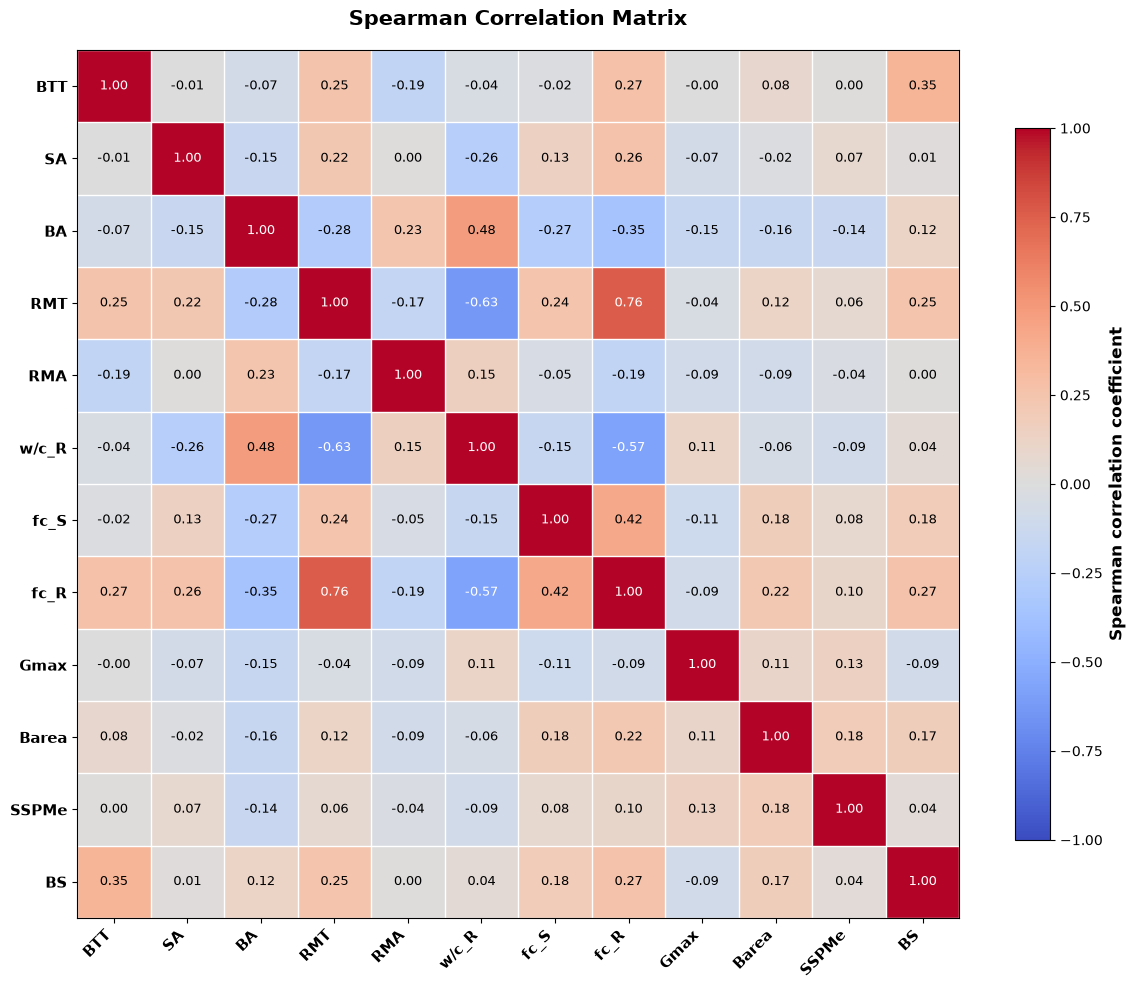

In [19]:
# ============================================================
# SECTION 11B: SPEARMAN CORRELATION HEATMAP
# ============================================================

from matplotlib.colors import TwoSlopeNorm
from pandas.api.types import is_numeric_dtype

# Output folder
if "OUT" not in globals():
    OUT = "analysis_outputs"
os.makedirs(OUT, exist_ok=True)

# ------------------------------------------------------------
# 1) Build dataframe for Spearman correlation
#    Use retained model features X + target y
# ------------------------------------------------------------
corr_df = X.copy()
corr_df["BS"] = y.values

# ------------------------------------------------------------
# 2) Encode categorical variables correctly
# ------------------------------------------------------------
corr_encoded = corr_df.copy()
encoding_maps = {}

for col in corr_encoded.columns:

    # If column is not numeric, encode it
    if not is_numeric_dtype(corr_encoded[col]):

        # Convert to clean string first
        clean_col = corr_encoded[col].astype(str).str.strip()

        # Factorize categorical values
        codes, uniques = pd.factorize(clean_col, sort=True)

        corr_encoded[col] = codes

        # Store encoding map for checking
        encoding_maps[col] = {
            category: code for code, category in enumerate(uniques)
        }

# Convert all columns to numeric safely
corr_encoded = corr_encoded.apply(pd.to_numeric, errors="coerce")

# ------------------------------------------------------------
# 3) Print categorical encoding maps
# ------------------------------------------------------------
print("\n── Categorical Encoding Used for Spearman ─────────────")

if len(encoding_maps) == 0:
    print("No categorical variables were detected.")
else:
    for col, mapping in encoding_maps.items():
        print(f"\n[{col}]")
        for category, code in mapping.items():
            print(f"  {category} -> {code}")

# Save encoding map
encoding_txt_path = os.path.join(OUT, "EDA_spearman_categorical_encoding.txt")

with open(encoding_txt_path, "w", encoding="utf-8") as f:
    for col, mapping in encoding_maps.items():
        f.write(f"[{col}]\n")
        for category, code in mapping.items():
            f.write(f"{category} -> {code}\n")
        f.write("\n")

print(f"\nSaved categorical encoding map → {encoding_txt_path}")

# ------------------------------------------------------------
# 4) Calculate Spearman correlation matrix
# ------------------------------------------------------------
spearman_corr = corr_encoded.corr(method="spearman")

# Save correlation matrix
spearman_csv_path = os.path.join(OUT, "EDA_spearman_correlation_matrix.csv")
spearman_corr.to_csv(spearman_csv_path)

print("\nSpearman correlation matrix saved to:")
print(spearman_csv_path)

# ------------------------------------------------------------
# 5) Plot Spearman correlation heatmap
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 10))

norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

im = ax.imshow(
    spearman_corr.values,
    cmap="coolwarm",
    norm=norm,
    aspect="auto"
)

# Axis labels
ax.set_xticks(np.arange(len(spearman_corr.columns)))
ax.set_yticks(np.arange(len(spearman_corr.index)))

ax.set_xticklabels(
    spearman_corr.columns,
    rotation=45,
    ha="right",
    fontsize=11,
    fontweight="bold"
)

ax.set_yticklabels(
    spearman_corr.index,
    fontsize=11,
    fontweight="bold"
)

# Add correlation values inside cells
for i in range(len(spearman_corr.index)):
    for j in range(len(spearman_corr.columns)):
        value = spearman_corr.iloc[i, j]

        if pd.isna(value):
            text = ""
            text_color = "black"
        else:
            text = f"{value:.2f}"
            text_color = "white" if abs(value) >= 0.50 else "black"

        ax.text(
            j,
            i,
            text,
            ha="center",
            va="center",
            color=text_color,
            fontsize=9
        )

# Grid lines
ax.set_xticks(np.arange(-0.5, len(spearman_corr.columns), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(spearman_corr.index), 1), minor=True)

ax.grid(which="minor", color="white", linestyle="-", linewidth=1.0)
ax.tick_params(which="minor", bottom=False, left=False)

# Colorbar
cbar = fig.colorbar(im, ax=ax, shrink=0.82)
cbar.set_label(
    "Spearman correlation coefficient",
    fontsize=12,
    fontweight="bold"
)
cbar.ax.tick_params(labelsize=10)

# Title
ax.set_title(
    "Spearman Correlation Matrix",
    fontsize=15,
    fontweight="bold",
    pad=18
)

plt.tight_layout()

# Save figure
spearman_fig_path = os.path.join(OUT, "EDA_spearman_correlation_heatmap.png")

fig.savefig(
    spearman_fig_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

print("\nSpearman heatmap saved to:")
print(spearman_fig_path)

plt.show()
plt.close(fig)

In [22]:
# ============================================================
# SECTION 12: CATBOOST REGRESSOR
# ============================================================

from sklearn.model_selection import RandomizedSearchCV

# Categorical feature indices required by CatBoost API
cat_features_idx = [X.columns.get_loc(c) for c in CATEGORICAL_COLS]

cat_model = CatBoostRegressor(
    verbose=0,
    random_state=RANDOM_STATE,
    allow_writing_files=False
)

# Hyperparameters reported in manuscript
param_dist_cat = {
    "depth":               [4, 6, 8, 10],
    "learning_rate":       [0.01, 0.03, 0.05, 0.1],
    "iterations":          [500, 800, 1200, 1500],
    "l2_leaf_reg":         [1, 3, 5, 7],
    "bagging_temperature": [0, 0.5, 1],
}

cat_search = RandomizedSearchCV(
    estimator=cat_model,
    param_distributions=param_dist_cat,
    n_iter=30,              # tests 40 random combinations instead of all 768
    scoring="r2",
    cv=5,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
)

cat_search.fit(
    X_train,
    y_train,
    cat_features=cat_features_idx
)

best_cat = cat_search.best_estimator_

print("\nCatBoost — Best Params:", cat_search.best_params_)
print("CatBoost — Best CV R²  :", cat_search.best_score_)

# Retrain best model with early stopping on the held-out test set
best_cat.fit(
    X_train,
    y_train,
    cat_features=cat_features_idx,
    eval_set=(X_test, y_test),
    early_stopping_rounds=50,
    verbose=100,
)

# ── 12A: CatBoost Evaluation (Train & Test) ──────────────────

y_pred_cat       = best_cat.predict(X_test)
y_pred_cat_train = best_cat.predict(X_train)

# Test metrics
rmse_cat = np.sqrt(mean_squared_error(y_test, y_pred_cat))
mae_cat  = mean_absolute_error(y_test, y_pred_cat)
r2_cat   = r2_score(y_test, y_pred_cat)

# Training metrics
rmse_cat_train = np.sqrt(mean_squared_error(y_train, y_pred_cat_train))
mae_cat_train  = mean_absolute_error(y_train, y_pred_cat_train)
r2_cat_train   = r2_score(y_train, y_pred_cat_train)

print("\n── CatBoost Performance ────────────────────────────────")
print(f"  {'Metric':<6}  {'Train':>10}  {'Test':>10}")
print(f"  {'-'*30}")
print(f"  {'RMSE':<6}  {rmse_cat_train:>10.4f}  {rmse_cat:>10.4f}")
print(f"  {'MAE':<6}  {mae_cat_train:>10.4f}  {mae_cat:>10.4f}")
print(f"  {'R²':<6}  {r2_cat_train:>10.4f}  {r2_cat:>10.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

CatBoost — Best Params: {'learning_rate': 0.05, 'l2_leaf_reg': 3, 'iterations': 800, 'depth': 6, 'bagging_temperature': 0}
CatBoost — Best CV R²  : 0.9082563054816927
0:	learn: 8.4527111	test: 7.8272260	best: 7.8272260 (0)	total: 95.9ms	remaining: 1m 16s
100:	learn: 2.6353922	test: 2.8764332	best: 2.8764086 (99)	total: 10.6s	remaining: 1m 13s
200:	learn: 2.2242277	test: 2.6679726	best: 2.6679726 (200)	total: 21s	remaining: 1m 2s
300:	learn: 1.9789645	test: 2.5524851	best: 2.5511898 (298)	total: 31.7s	remaining: 52.6s
400:	learn: 1.8206510	test: 2.4725046	best: 2.4715757 (399)	total: 42.7s	remaining: 42.4s
500:	learn: 1.6819992	test: 2.4385165	best: 2.4375906 (498)	total: 53.2s	remaining: 31.8s
600:	learn: 1.5668528	test: 2.4108275	best: 2.4091542 (597)	total: 1m 3s	remaining: 21.2s
700:	learn: 1.4709433	test: 2.3922911	best: 2.3922911 (700)	total: 1m 14s	remaining: 10.5s
799:	learn: 1.3897932	test: 2.3858854	best: 2.3858797

In [23]:
# SECTION 13: DECISION TREE REGRESSOR

dt_model = DecisionTreeRegressor(random_state=RANDOM_STATE)

# Hyperparameters reported in manuscript
param_dist_dt = {
    "max_depth":         [5, 10, 15, 20],
    "min_samples_split": [5, 10, 20],
    "min_samples_leaf":  list(range(1, 20)),
    "max_features":      [None, "sqrt", "log2"],
    "ccp_alpha":         np.linspace(0.0, 0.02, 50),
}

cv_rk = RepeatedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)

dt_search = RandomizedSearchCV(
    dt_model,
    param_distributions=param_dist_dt,
    n_iter=100,
    scoring="r2",
    cv=cv_rk,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
)

dt_search.fit(X_train_enc, y_train)

best_dt          = dt_search.best_estimator_
y_pred_dt        = best_dt.predict(X_test_enc)
y_pred_dt_train  = best_dt.predict(X_train_enc)

# Test metrics
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
mae_dt  = mean_absolute_error(y_test, y_pred_dt)
r2_dt   = r2_score(y_test, y_pred_dt)

# Training metrics
rmse_dt_train = np.sqrt(mean_squared_error(y_train, y_pred_dt_train))
mae_dt_train  = mean_absolute_error(y_train, y_pred_dt_train)
r2_dt_train   = r2_score(y_train, y_pred_dt_train)

print("\n── Decision Tree Performance ────────────────────────────")
print("  Best Params:", dt_search.best_params_)
print(f"  {'Metric':<6}  {'Train':>10}  {'Test':>10}")
print(f"  {'-'*30}")
print(f"  {'RMSE':<6}  {rmse_dt_train:>10.4f}  {rmse_dt:>10.4f}")
print(f"  {'MAE':<6}  {mae_dt_train:>10.4f}  {mae_dt:>10.4f}")
print(f"  {'R²':<6}  {r2_dt_train:>10.4f}  {r2_dt:>10.4f}")

Fitting 15 folds for each of 100 candidates, totalling 1500 fits

── Decision Tree Performance ────────────────────────────
  Best Params: {'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 20, 'ccp_alpha': np.float64(0.0012244897959183673)}
  Metric       Train        Test
  ------------------------------
  RMSE        1.4771      3.0988
  MAE         0.7924      1.7732
  R²          0.9714      0.8545


In [24]:
# ============================================================
# SECTION 14: RANDOM FOREST REGRESSOR
# ============================================================

rf_model = RandomForestRegressor(
    random_state=RANDOM_STATE,
    oob_score=True,   # OOB gives a free validation estimate
    n_jobs=-1,
)

# Hyperparameters reported in manuscript
param_dist_rf = {
    "n_estimators":      [300, 500, 800, 1200, 1500],
    "max_depth":         [None, 20, 30, 40, 50],
    "min_samples_split": [2, 5, 10, 15, 20],
    "min_samples_leaf":  [1, 2, 3],
    "max_features":      [0.3, 0.5, 0.6, 0.8],
    "bootstrap":         [True],
}

rf_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist_rf,
    n_iter=100,
    scoring="r2",
    cv=cv_rk,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
    error_score="raise",
)

rf_search.fit(X_train_enc, y_train)

best_rf          = rf_search.best_estimator_
y_pred_rf        = best_rf.predict(X_test_enc)
y_pred_rf_train  = best_rf.predict(X_train_enc)

# Test metrics
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

# Training metrics
rmse_rf_train = np.sqrt(mean_squared_error(y_train, y_pred_rf_train))
mae_rf_train  = mean_absolute_error(y_train, y_pred_rf_train)
r2_rf_train   = r2_score(y_train, y_pred_rf_train)

print("\n── Random Forest Performance ────────────────────────────")
print("  Best Params:", rf_search.best_params_)
print(f"  OOB Score : {best_rf.oob_score_:.4f}")
print(f"  {'Metric':<6}  {'Train':>10}  {'Test':>10}")
print(f"  {'-'*30}")
print(f"  {'RMSE':<6}  {rmse_rf_train:>10.4f}  {rmse_rf:>10.4f}")
print(f"  {'MAE':<6}  {mae_rf_train:>10.4f}  {mae_rf:>10.4f}")
print(f"  {'R²':<6}  {r2_rf_train:>10.4f}  {r2_rf:>10.4f}")

Fitting 15 folds for each of 100 candidates, totalling 1500 fits

── Random Forest Performance ────────────────────────────
  Best Params: {'n_estimators': 800, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.8, 'max_depth': 50, 'bootstrap': True}
  OOB Score : 0.9017
  Metric       Train        Test
  ------------------------------
  RMSE        1.5821      2.5049
  MAE         0.8765      1.4230
  R²          0.9672      0.9049


In [26]:
# ============================================================
# SECTION 15: XGBOOST REGRESSOR
# ============================================================

# Use a sub-split of the training set as a validation set
# so early stopping works correctly without touching the test set.
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train_enc, y_train, test_size=0.2, random_state=RANDOM_STATE
)

# ── 15A: Hyperparameter Search (no early stopping here) ─────

xgb_base = XGBRegressor(
    random_state=RANDOM_STATE,
    tree_method="hist",
    verbosity=0,
    n_jobs=-1,
    eval_metric="rmse",
)

# Hyperparameters reported in manuscript
param_dist_xgb = {
    "n_estimators":     [800, 1200, 1500, 2000],
    "learning_rate":    [0.01, 0.03, 0.05, 0.1],
    "max_depth":        [6, 8, 10, 12, 14],
    "min_child_weight": [3, 5, 7, 9],
    "subsample":        [0.4, 0.5, 0.6, 0.7],
    "colsample_bytree": [0.4, 0.5, 0.6, 0.7],
    "gamma":            [0, 0.1, 0.2, 0.3],
    "reg_alpha":        [0.5, 1, 2, 5],
    "reg_lambda":       [3, 5, 7, 10],
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist_xgb,
    n_iter=50,
    scoring="r2",
    cv=5,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
)

xgb_search.fit(X_train_sub, y_train_sub)

# ── 15B: Retrain Best XGB with Early Stopping ───────────────

best_params_xgb = xgb_search.best_params_

best_xgb = XGBRegressor(
    **best_params_xgb,
    random_state=RANDOM_STATE,
    tree_method="hist",
    verbosity=0,
    n_jobs=-1,
    eval_metric="rmse",
    early_stopping_rounds=50,
)

best_xgb.fit(
    X_train_sub,
    y_train_sub,
    eval_set=[(X_val, y_val)],
    verbose=False,
)

# ── 15C: XGBoost Evaluation (Train & Test) ───────────────────

y_pred_xgb       = best_xgb.predict(X_test_enc)
y_pred_xgb_train = best_xgb.predict(X_train_enc)

# Test metrics
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb   = r2_score(y_test, y_pred_xgb)

# Training metrics
rmse_xgb_train = np.sqrt(mean_squared_error(y_train, y_pred_xgb_train))
mae_xgb_train  = mean_absolute_error(y_train, y_pred_xgb_train)
r2_xgb_train   = r2_score(y_train, y_pred_xgb_train)

print("\n── XGBoost Performance ──────────────────────────────────")
print("  Best Params:", best_params_xgb)
print(f"  {'Metric':<6}  {'Train':>10}  {'Test':>10}")
print(f"  {'-'*30}")
print(f"  {'RMSE':<6}  {rmse_xgb_train:>10.4f}  {rmse_xgb:>10.4f}")
print(f"  {'MAE':<6}  {mae_xgb_train:>10.4f}  {mae_xgb:>10.4f}")
print(f"  {'R²':<6}  {r2_xgb_train:>10.4f}  {r2_xgb:>10.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits

── XGBoost Performance ──────────────────────────────────
  Best Params: {'subsample': 0.7, 'reg_lambda': 10, 'reg_alpha': 5, 'n_estimators': 2000, 'min_child_weight': 9, 'max_depth': 6, 'learning_rate': 0.03, 'gamma': 0.3, 'colsample_bytree': 0.5}
  Metric       Train        Test
  ------------------------------
  RMSE        2.0069      2.8147
  MAE         1.1338      1.6281
  R²          0.9472      0.8799


In [29]:
# SECTION 16: MODEL COMPARISON SUMMARY (Train & Test)
# ============================================================

results = {
    "CatBoost": {
        "RMSE_train": rmse_cat_train, "MAE_train": mae_cat_train, "R²_train": r2_cat_train,
        "RMSE_test":  rmse_cat,       "MAE_test":  mae_cat,       "R²_test":  r2_cat,
    },
    "Decision Tree": {
        "RMSE_train": rmse_dt_train,  "MAE_train": mae_dt_train,  "R²_train": r2_dt_train,
        "RMSE_test":  rmse_dt,        "MAE_test":  mae_dt,        "R²_test":  r2_dt,
    },
    "Random Forest": {
        "RMSE_train": rmse_rf_train,  "MAE_train": mae_rf_train,  "R²_train": r2_rf_train,
        "RMSE_test":  rmse_rf,        "MAE_test":  mae_rf,        "R²_test":  r2_rf,
    },
    "XGBoost": {
        "RMSE_train": rmse_xgb_train, "MAE_train": mae_xgb_train, "R²_train": r2_xgb_train,
        "RMSE_test":  rmse_xgb,       "MAE_test":  mae_xgb,       "R²_test":  r2_xgb,
    },
}

W = 82
print("\n" + "=" * W)
print("  FINAL MODEL COMPARISON — TRAINING vs TEST")
print("=" * W)
print(f"  {'Model':<18}  "
      f"{'RMSE(Tr)':>10}  {'RMSE(Te)':>10}  "
      f"{'MAE(Tr)':>10}  {'MAE(Te)':>10}  "
      f"{'R²(Tr)':>9}  {'R²(Te)':>9}")
print("  " + "-" * (W - 2))
for model_name, m in results.items():
    print(
        f"  {model_name:<18}  "
        f"{m['RMSE_train']:>10.4f}  {m['RMSE_test']:>10.4f}  "
        f"{m['MAE_train']:>10.4f}  {m['MAE_test']:>10.4f}  "
        f"{m['R²_train']:>9.4f}  {m['R²_test']:>9.4f}"
    )
print("=" * W)



  FINAL MODEL COMPARISON — TRAINING vs TEST
  Model                 RMSE(Tr)    RMSE(Te)     MAE(Tr)     MAE(Te)     R²(Tr)     R²(Te)
  --------------------------------------------------------------------------------
  CatBoost                1.5948      2.3859      1.0076      1.4833     0.9667     0.9137
  Decision Tree           1.4771      3.0988      0.7924      1.7732     0.9714     0.8545
  Random Forest           1.5821      2.5049      0.8765      1.4230     0.9672     0.9049
  XGBoost                 2.0069      2.8147      1.1338      1.6281     0.9472     0.8799


In [28]:
# ============================================================
# SECTION 16B: HYPERPARAMETER BOUNDARY CHECK
# ============================================================
#
#  After tuning, it is important to verify that no best
#  hyperparameter landed on the boundary of its search range.
#  A boundary hit means the true optimum likely lies OUTSIDE
#  the range that was searched — the search should be widened
#  and rerun for that parameter.
#
#  For each model the function below:
#    1. Compares each best value against the min and max of
#       its search range.
#    2. Flags boundary hits with a ⚠️  warning.
#    3. Confirms interior values with ✅.
#    4. Skips parameters whose search space has no natural
#       boundary concept (e.g. None, string choices).
# ────────────────────────────────────────────────────────────

def _check_boundaries(model_name, best_params, param_dist):
    """
    Compare best hyperparameter values against their search
    range boundaries and report any boundary hits.

    Parameters
    ----------
    model_name  : str — label for console output
    best_params : dict — {param: best_value} from search.best_params_
    param_dist  : dict — {param: list_of_values} search space
    """
    print(f"\n── {model_name} — Hyperparameter Boundary Check ──────")

    boundary_hits = []

    for param, best_val in best_params.items():
        if param not in param_dist:
            continue

        space = param_dist[param]

        # Filter to numeric values only — skip None and strings
        numeric_space = [
            v for v in space
            if isinstance(v, (int, float)) and v is not None
        ]

        if len(numeric_space) < 2:
            # Not enough numeric values to define a boundary
            print(f"  {'—':>3}  {param:<26}  best={best_val!r:<12}  "
                  f"(non-numeric / single-value space — skip)")
            continue

        lo = min(numeric_space)
        hi = max(numeric_space)

        if not isinstance(best_val, (int, float)):
            print(f"  {'—':>3}  {param:<26}  best={best_val!r:<12}  "
                  f"(non-numeric best value — skip)")
            continue

        at_lo = abs(best_val - lo) < 1e-9
        at_hi = abs(best_val - hi) < 1e-9

        if at_lo or at_hi:
            side = "LOWER" if at_lo else "UPPER"
            print(f"  ⚠️   {param:<26}  best={best_val!r:<12}  "
                  f"→ AT {side} BOUNDARY  "
                  f"[range: {lo} – {hi}]  — consider widening")
            boundary_hits.append((param, best_val, side, lo, hi))
        else:
            print(f"  ✅   {param:<26}  best={best_val!r:<12}  "
                  f"[range: {lo} – {hi}]")

    if not boundary_hits:
        print(f"  → All parameters are interior to their search ranges. ✅")
    else:
        print(f"\n  ⚠️  {len(boundary_hits)} boundary hit(s) detected — "
              f"see parameters flagged above.")
        print("     Recommendation: extend the flagged range(s) and rerun "
              "the search.")

    return boundary_hits


# ── Run boundary check for all four models ────────────────────

boundary_report = {}

boundary_report["CatBoost"] = _check_boundaries(
    model_name  = "CatBoost",
    best_params = cat_search.best_params_,
    param_dist  = param_dist_cat,
)

boundary_report["Decision Tree"] = _check_boundaries(
    model_name  = "Decision Tree",
    best_params = dt_search.best_params_,
    param_dist  = param_dist_dt,
)

boundary_report["Random Forest"] = _check_boundaries(
    model_name  = "Random Forest",
    best_params = rf_search.best_params_,
    param_dist  = param_dist_rf,
)

boundary_report["XGBoost"] = _check_boundaries(
    model_name  = "XGBoost",
    best_params = xgb_search.best_params_,
    param_dist  = param_dist_xgb,
)

# ── Overall summary ───────────────────────────────────────────
total_hits = sum(len(v) for v in boundary_report.values())
print("\n" + "=" * 58)
print(f"  BOUNDARY CHECK SUMMARY")
print("=" * 58)
if total_hits == 0:
    print("  ✅ No boundary hits across any model.")
    print("     Search ranges are well-calibrated.")
else:
    print(f"  ⚠️  {total_hits} total boundary hit(s) detected:")
    for model_name, hits in boundary_report.items():
        if hits:
            for param, val, side, lo, hi in hits:
                print(f"     • {model_name} — {param} = {val!r}  "
                      f"({side} boundary, range {lo}–{hi})")
    print("\n  Action: widen the flagged range(s) and rerun tuning.")
print("=" * 58)



── CatBoost — Hyperparameter Boundary Check ──────
  ✅   learning_rate               best=0.05          [range: 0.01 – 0.1]
  ✅   l2_leaf_reg                 best=3             [range: 1 – 7]
  ✅   iterations                  best=800           [range: 500 – 1500]
  ✅   depth                       best=6             [range: 4 – 10]
  ⚠️   bagging_temperature         best=0             → AT LOWER BOUNDARY  [range: 0 – 1]  — consider widening

  ⚠️  1 boundary hit(s) detected — see parameters flagged above.
     Recommendation: extend the flagged range(s) and rerun the search.

── Decision Tree — Hyperparameter Boundary Check ──────
  ⚠️   min_samples_split           best=5             → AT LOWER BOUNDARY  [range: 5 – 20]  — consider widening
  ✅   min_samples_leaf            best=2             [range: 1 – 19]
    —  max_features                best=None          (non-numeric / single-value space — skip)
  ⚠️   max_depth                   best=20            → AT UPPER BOUNDARY  [range: 

In [30]:
# ============================================================
# SECTION 18: MODEL DIAGNOSTIC PLOTS
# ============================================================
#
#  Shared styling helpers, learning curves, actual vs predicted
#  scatter plots, and residual plots — one set per model.
#
#  18A  CatBoost learning curve
#  18B  Decision Tree learning curve
#  18C  Random Forest learning curve
#  18D  XGBoost learning curve
#  18E  Actual vs Predicted (all 4 models)
#  18F  Residual plots (all 4 models)
# ────────────────────────────────────────────────────────────

#
#  All plots from §19 onward use a single consistent style:
#    • Times New Roman, bold, no italics
#    • Thick spines (1.5 pt), inward ticks
#    • No grid lines
#    • 300 dpi output saved to OUT/
# ────────────────────────────────────────────────────────────

import matplotlib as mpl
from matplotlib.patches import Patch

# Apply journal-wide rcParams once — affects all subsequent plots
mpl.rcParams.update({
    "font.family":       "serif",
    "font.serif":        ["Times New Roman", "DejaVu Serif"],
    "font.weight":       "bold",
    "axes.titleweight":  "bold",
    "axes.labelweight":  "bold",
    "axes.linewidth":    1.5,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.direction":   "in",
    "ytick.direction":   "in",
    "xtick.labelsize":   11,
    "ytick.labelsize":   11,
    "legend.fontsize":   10,
    "legend.frameon":    True,
    "savefig.dpi":       300,
    "savefig.bbox":      "tight",
    "savefig.facecolor": "white",
})


def _style_ax(ax, title, xlabel, ylabel):
    """Apply uniform journal styling to a matplotlib Axes object."""
    ax.set_title(title,   fontsize=13, fontweight="bold")
    ax.set_xlabel(xlabel, fontsize=12, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=12, fontweight="bold")
    ax.tick_params(axis="both", which="major", labelsize=11)
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontweight("bold")
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
    ax.grid(False)


def _save_show(fig, path):
    """Save figure then close cleanly (prevents double-render)."""
    if path:
        fig.savefig(path, dpi=300, bbox_inches="tight", facecolor="white")
        print(f"  Saved → {path}")
    plt.show(block=False)
    plt.pause(0.1)
    plt.close(fig)


# ============================================================
#
#  Plots training vs. cross-validation R² as a function of
#  training set size for each model.
#  CatBoost uses raw X (with categorical cols);
#  DT / RF / XGB use the OHE-encoded X.
# ────────────────────────────────────────────────────────────

def plot_learning_curve(model, X, y, title,
                        train_color, val_color,
                        cv=5, scoring="r2",
                        save_path=None):
    """
    Parameters
    ----------
    model        : fitted or unfitted estimator
    X, y         : feature matrix and target (training set only)
    title        : figure title string
    train_color  : colour for the training score line
    val_color    : colour for the CV validation score line
    cv           : cross-validation strategy or int
    scoring      : sklearn scoring string (default 'r2')
    save_path    : file path to save the figure
    """
    train_sizes, train_scores, val_scores = learning_curve(
        estimator=model,
        X=X, y=y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5),
        shuffle=True,
        random_state=RANDOM_STATE,
    )

    tr_mean, tr_std = train_scores.mean(1), train_scores.std(1)
    cv_mean, cv_std = val_scores.mean(1),   val_scores.std(1)

    fig, ax = plt.subplots(figsize=(8, 6))

    # Training curve
    ax.plot(train_sizes, tr_mean,
            color=train_color, linewidth=2.5, label="Training score")
    ax.fill_between(train_sizes, tr_mean - tr_std, tr_mean + tr_std,
                    color=train_color, alpha=0.15)

    # CV curve
    ax.plot(train_sizes, cv_mean,
            color=val_color, linewidth=2.5, label="CV score")
    ax.fill_between(train_sizes, cv_mean - cv_std, cv_mean + cv_std,
                    color=val_color, alpha=0.15)

    _style_ax(ax, title,
              xlabel="Number of training samples",
              ylabel="Coefficient of determination (R²)")
    ax.legend(loc="lower right")

    plt.tight_layout()
    _save_show(fig, save_path)


  Saved → analysis_outputs\LC_CatBoost.png


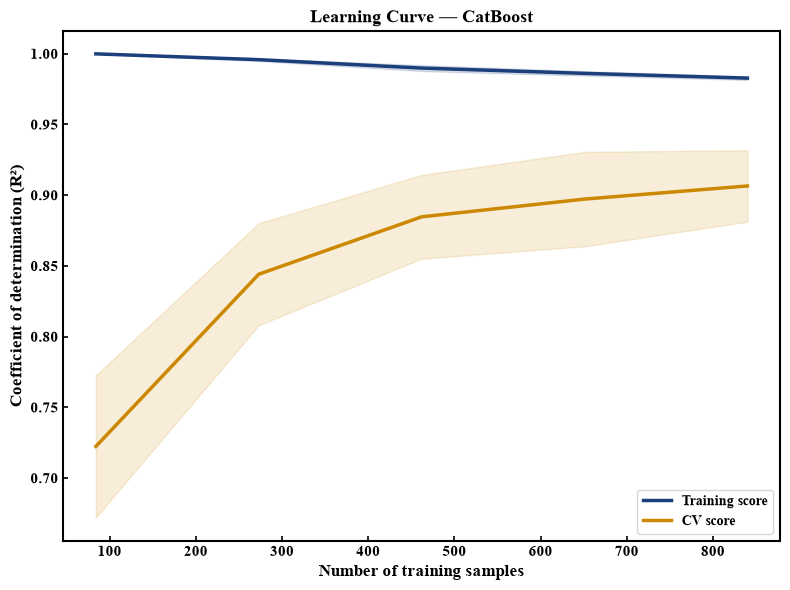

  Saved → analysis_outputs\LC_DecisionTree.png


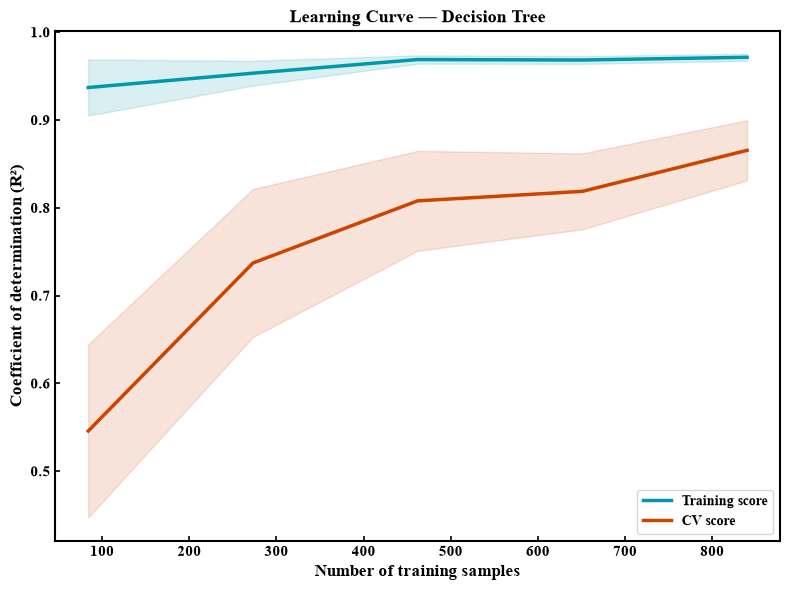

  Saved → analysis_outputs\LC_RandomForest.png


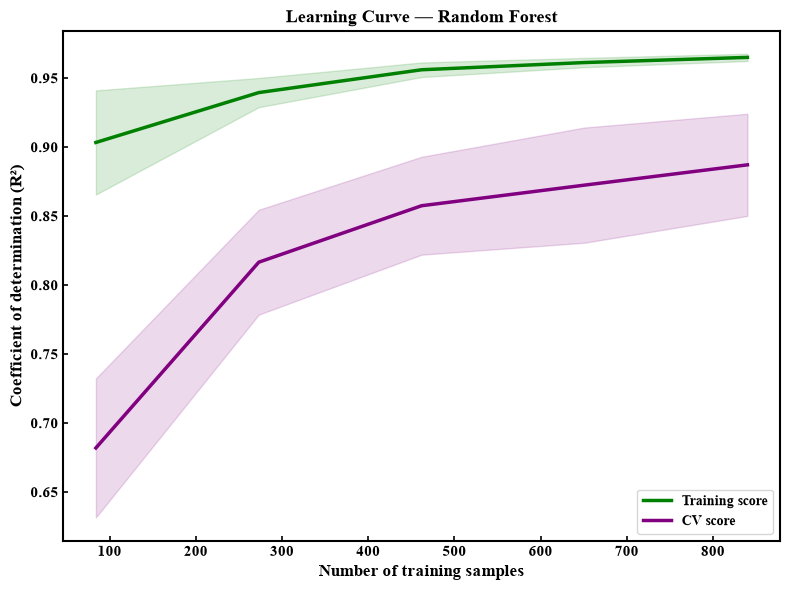

  Saved → analysis_outputs\LC_XGBoost.png


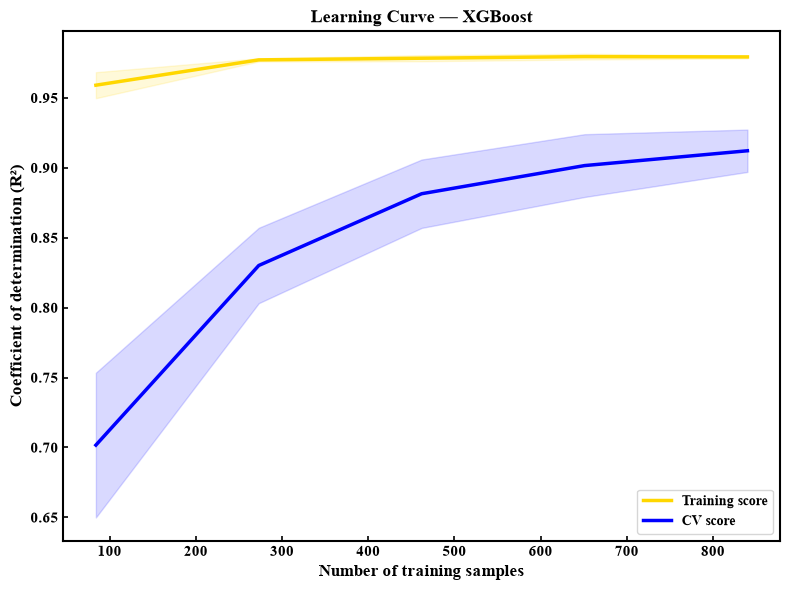

  Saved → analysis_outputs\AvP_CatBoost.png


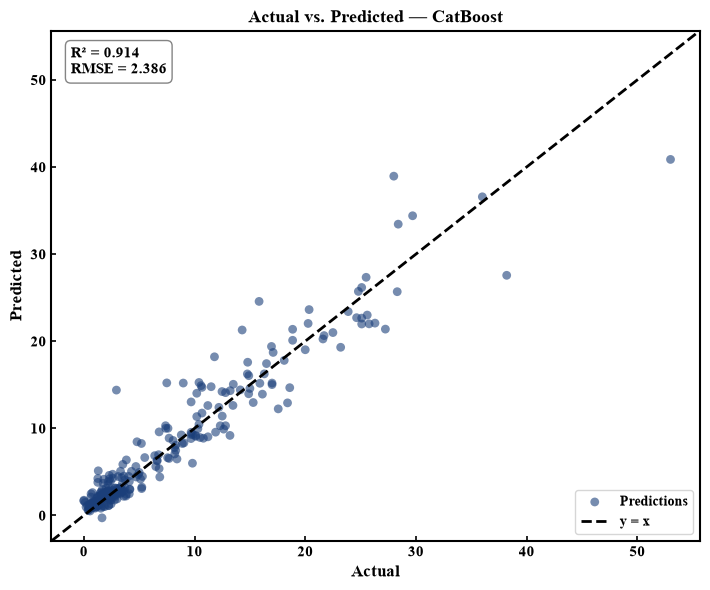

  Saved → analysis_outputs\Res_CatBoost.png


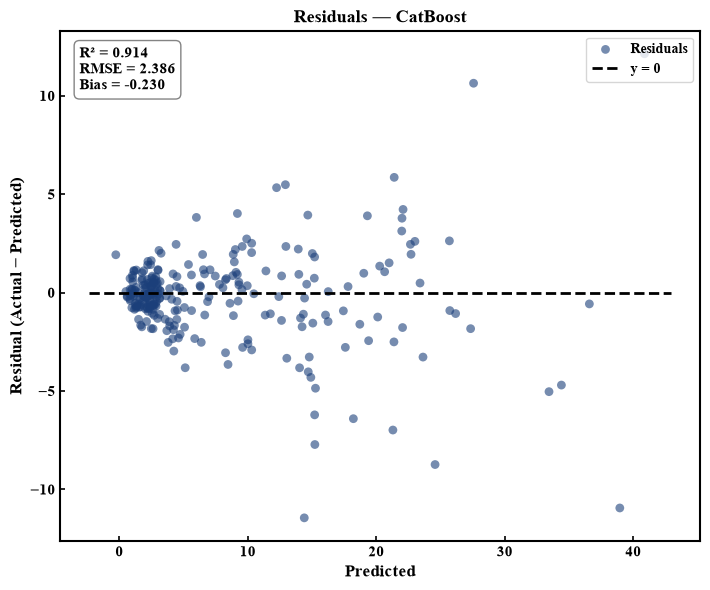

  Saved → analysis_outputs\AvP_Decision_Tree.png


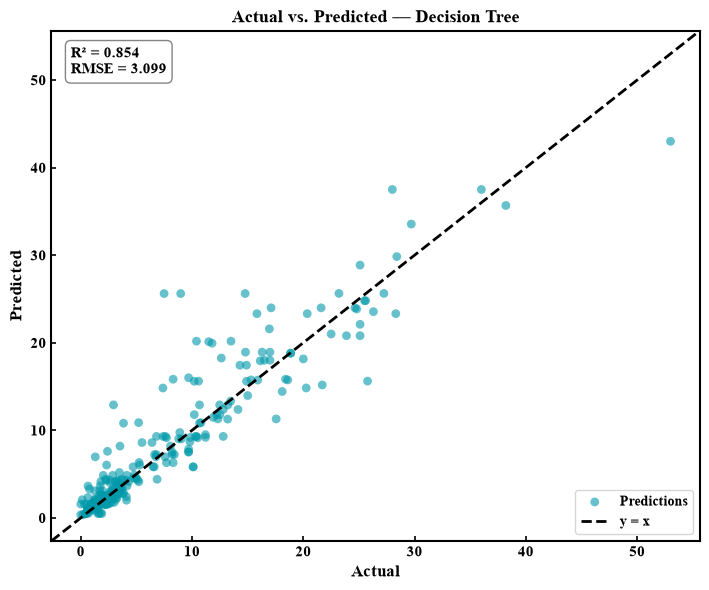

  Saved → analysis_outputs\Res_Decision_Tree.png


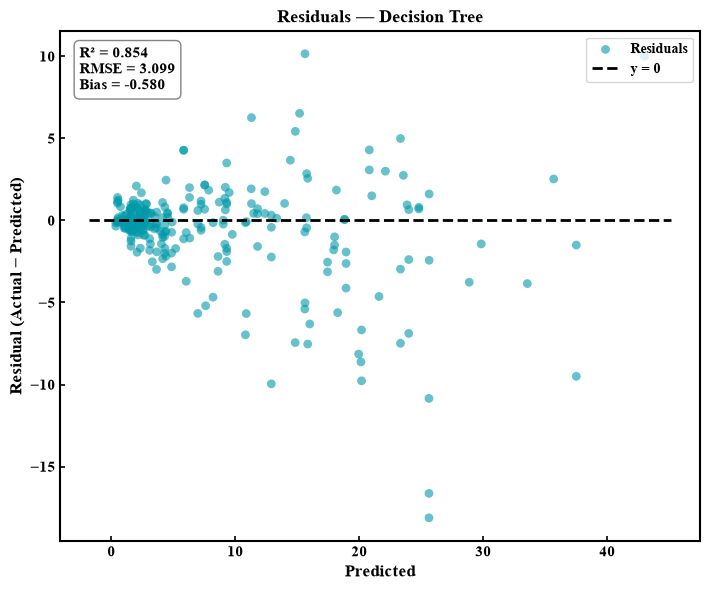

  Saved → analysis_outputs\AvP_Random_Forest.png


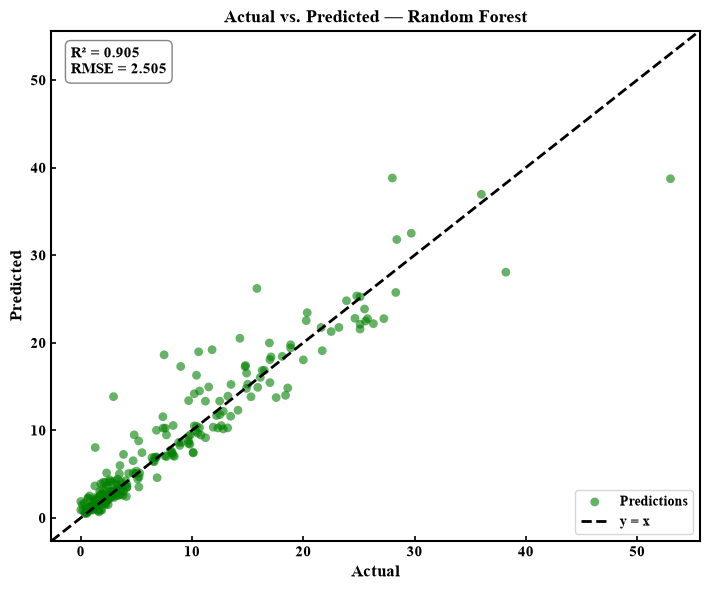

  Saved → analysis_outputs\Res_Random_Forest.png


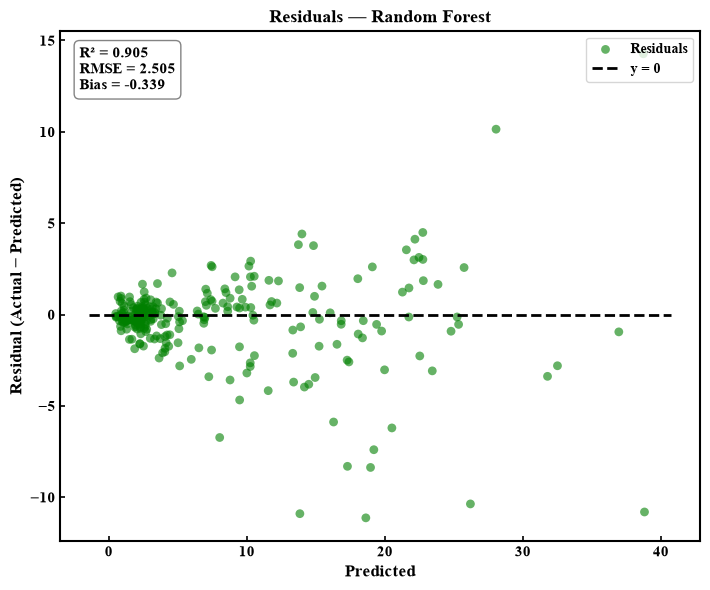

  Saved → analysis_outputs\AvP_XGBoost.png


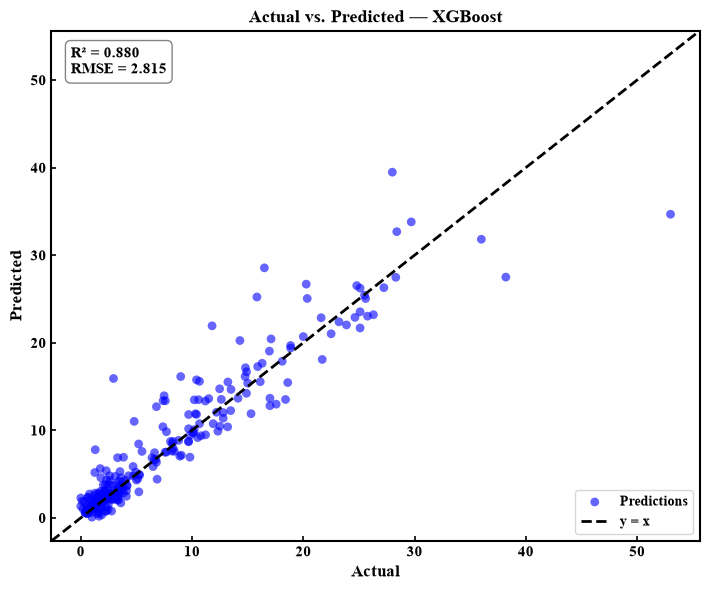

  Saved → analysis_outputs\Res_XGBoost.png


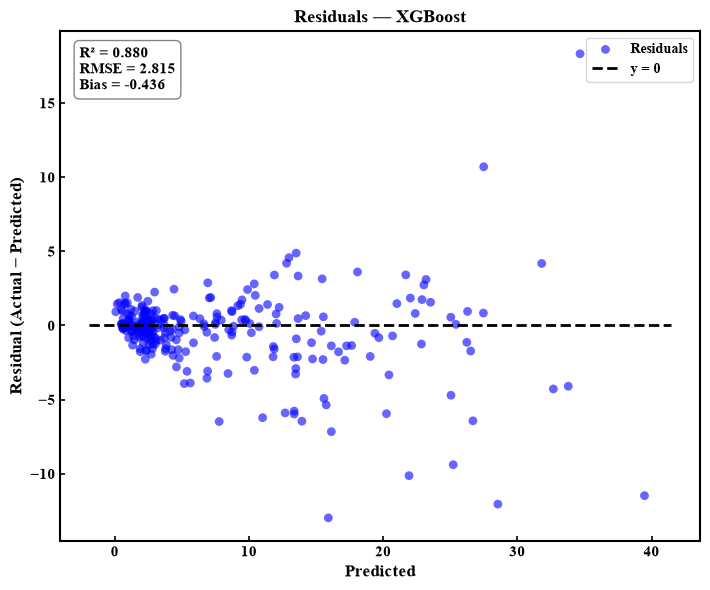

In [32]:
# ── 18A: CatBoost learning curve ─────────────────────────────
#
#  sklearn's learning_curve() clones the estimator internally
#  and calls plain .fit(X, y) — no cat_features argument is
#  passed to the clone.  Passing raw X (which still contains
#  string columns like BTT / RMT) therefore raises a
#  CatBoostError: "Cannot convert 'DT' to float".
#
#  Fix: supply the fully OHE-encoded X_train_enc (all-numeric)
#  and rebuild a plain CatBoostRegressor with the tuned params
#  so sklearn gets a valid, clonable, all-numeric estimator.

_cat_lc_model = CatBoostRegressor(
    **{k: v for k, v in cat_search.best_params_.items()},
    random_state = RANDOM_STATE,
    verbose      = 0,
)

plot_learning_curve(
    model       = _cat_lc_model,
    X           = X_train_enc,   # all-numeric, no cat_features needed
    y           = y_train,
    title       = "Learning Curve — CatBoost",
    train_color = "#1b3f7a",
    val_color   = "#cc8800",
    cv          = 5,
    save_path   = os.path.join(OUT, "LC_CatBoost.png"),
)

# ── 18B: Decision Tree learning curve ────────────────────────
plot_learning_curve(
    model       = best_dt,
    X           = X_train_enc,
    y           = y_train,
    title       = "Learning Curve — Decision Tree",
    train_color = "#0099aa",
    val_color   = "#cc4400",
    cv          = cv_rk,
    save_path   = os.path.join(OUT, "LC_DecisionTree.png"),
)

# ── 18C: Random Forest learning curve ────────────────────────
plot_learning_curve(
    model       = best_rf,
    X           = X_train_enc,
    y           = y_train,
    title       = "Learning Curve — Random Forest",
    train_color = "green",
    val_color   = "purple",
    cv          = cv_rk,
    save_path   = os.path.join(OUT, "LC_RandomForest.png"),
)

# ── 18D: XGBoost learning curve ──────────────────────────────
_xgb_lc_model = XGBRegressor(
    **best_params_xgb,
    random_state=RANDOM_STATE,
    tree_method="hist",
    verbosity=0,
    n_jobs=-1,
    eval_metric="rmse",
)

plot_learning_curve(
    model       = _xgb_lc_model,
    X           = X_train_enc,
    y           = y_train,
    title       = "Learning Curve — XGBoost",
    train_color = "gold",
    val_color   = "blue",
    cv          = 5,
    save_path   = os.path.join(OUT, "LC_XGBoost.png"),
)


# ============================================================
def plot_actual_vs_pred(model, X, y, title,
                        point_color, line_color="black",
                        save_path=None):
    """Scatter of actual vs. predicted with y=x reference line."""
    y_pred_local = model.predict(X)
    r2_local   = r2_score(y, y_pred_local)
    rmse_local = np.sqrt(mean_squared_error(y, y_pred_local))

    lo = float(min(np.min(y), np.min(y_pred_local)))
    hi = float(max(np.max(y), np.max(y_pred_local)))
    pad = 0.05 * max(hi - lo, 1.0)

    fig, ax = plt.subplots(figsize=(7.2, 6))
    ax.scatter(y, y_pred_local,
               color=point_color, alpha=0.6, s=40,
               edgecolor="none", label="Predictions")
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad],
            color=line_color, linestyle="--",
            linewidth=2.0, label="y = x")
    ax.set_xlim(lo - pad, hi + pad)
    ax.set_ylim(lo - pad, hi + pad)

    _style_ax(ax, title, xlabel="Actual", ylabel="Predicted")
    ax.legend(loc="lower right")
    ax.text(0.03, 0.97,
            f"R² = {r2_local:.3f}\nRMSE = {rmse_local:.3f}",
            transform=ax.transAxes, va="top", ha="left",
            fontsize=11, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.35",
                      facecolor="white", alpha=0.9, edgecolor="#777"))

    plt.tight_layout()
    _save_show(fig, save_path)


def plot_residuals(model, X, y, title,
                   point_color, line_color="black",
                   save_path=None):
    """Residual scatter (Actual − Predicted) vs. Predicted."""
    y_pred_local = model.predict(X)
    residuals    = np.asarray(y) - y_pred_local
    r2_local     = r2_score(y, y_pred_local)
    rmse_local   = np.sqrt(mean_squared_error(y, y_pred_local))
    bias_local   = float(np.mean(residuals))

    x_lo = float(np.min(y_pred_local))
    x_hi = float(np.max(y_pred_local))
    pad  = 0.05 * max(x_hi - x_lo, 1.0)

    fig, ax = plt.subplots(figsize=(7.2, 6))
    ax.scatter(y_pred_local, residuals,
               color=point_color, alpha=0.6, s=40,
               edgecolor="none", label="Residuals")
    ax.plot([x_lo - pad, x_hi + pad], [0, 0],
            color=line_color, linestyle="--",
            linewidth=2.0, label="y = 0")

    _style_ax(ax, title,
              xlabel="Predicted",
              ylabel="Residual (Actual − Predicted)")
    ax.legend(loc="upper right")
    ax.text(0.03, 0.97,
            f"R² = {r2_local:.3f}\nRMSE = {rmse_local:.3f}"
            f"\nBias = {bias_local:.3f}",
            transform=ax.transAxes, va="top", ha="left",
            fontsize=11, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.35",
                      facecolor="white", alpha=0.9, edgecolor="#777"))

    plt.tight_layout()
    _save_show(fig, save_path)


# ── Model colours (consistent across all diagnostic plots) ───
MODEL_STYLE = {
    "CatBoost":      {"color": "#1b3f7a", "X": X_test,     "y": y_test},
    "Decision Tree": {"color": "#0099aa", "X": X_test_enc, "y": y_test},
    "Random Forest": {"color": "green",   "X": X_test_enc, "y": y_test},
    "XGBoost":       {"color": "blue",    "X": X_test_enc, "y": y_test},
}

BEST_MODELS = {
    "CatBoost":      best_cat,
    "Decision Tree": best_dt,
    "Random Forest": best_rf,
    "XGBoost":       best_xgb,
}

for _mname, _mdl in BEST_MODELS.items():
    _st   = MODEL_STYLE[_mname]
    _slug = _mname.replace(" ", "_")

    plot_actual_vs_pred(
        model       = _mdl,
        X           = _st["X"],
        y           = _st["y"],
        title       = f"Actual vs. Predicted — {_mname}",
        point_color = _st["color"],
        save_path   = os.path.join(OUT, f"AvP_{_slug}.png"),
    )

    plot_residuals(
        model       = _mdl,
        X           = _st["X"],
        y           = _st["y"],
        title       = f"Residuals — {_mname}",
        point_color = _st["color"],
        save_path   = os.path.join(OUT, f"Res_{_slug}.png"),
    )



  Feature importance CSVs saved.
  Saved → analysis_outputs\FI_bar_CatBoost.png


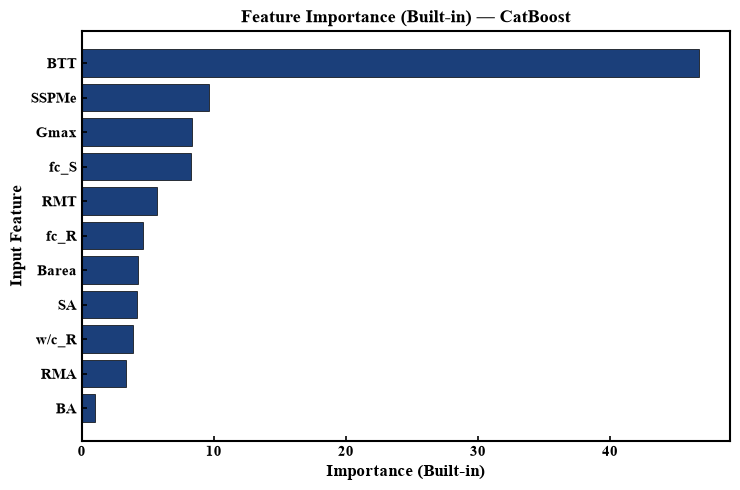

  Saved → analysis_outputs\PI_bar_CatBoost.png


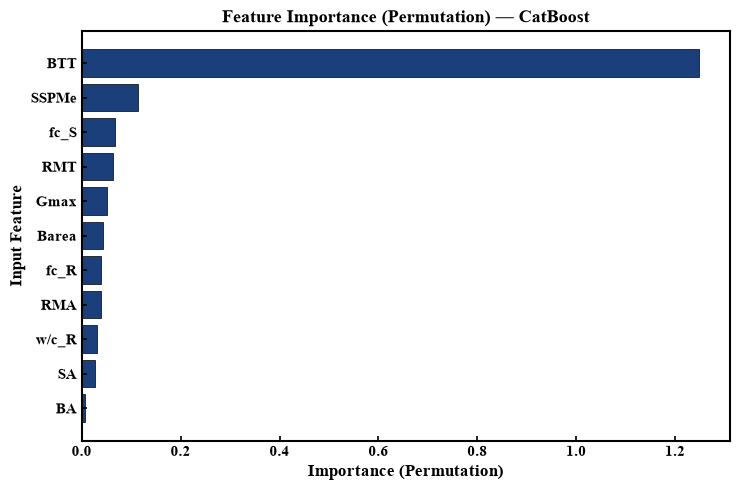

  Saved → analysis_outputs\SHAP_bar_CatBoost.png


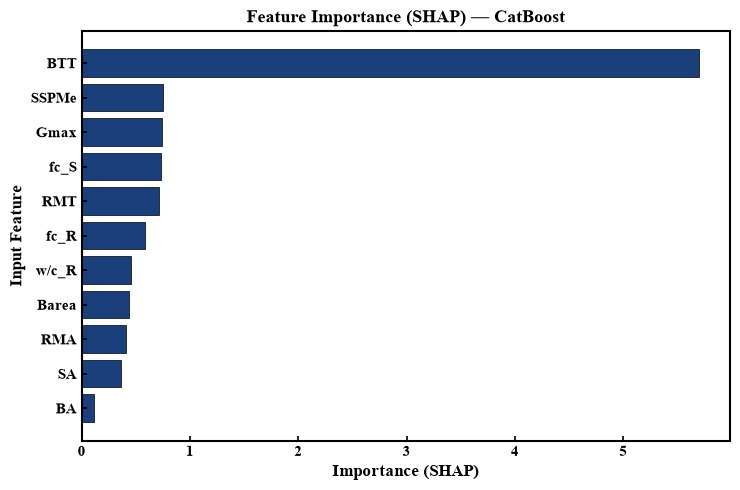

  Saved → analysis_outputs\FI_bar_DT.png


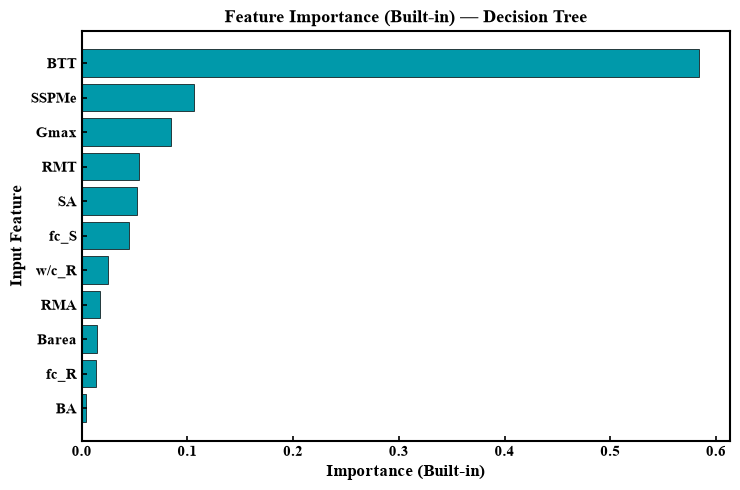

  Saved → analysis_outputs\PI_bar_DT.png


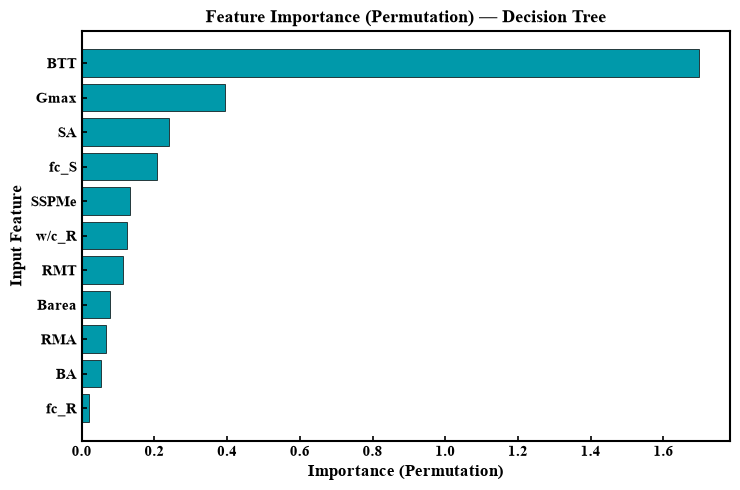

  Saved → analysis_outputs\SHAP_bar_DT.png


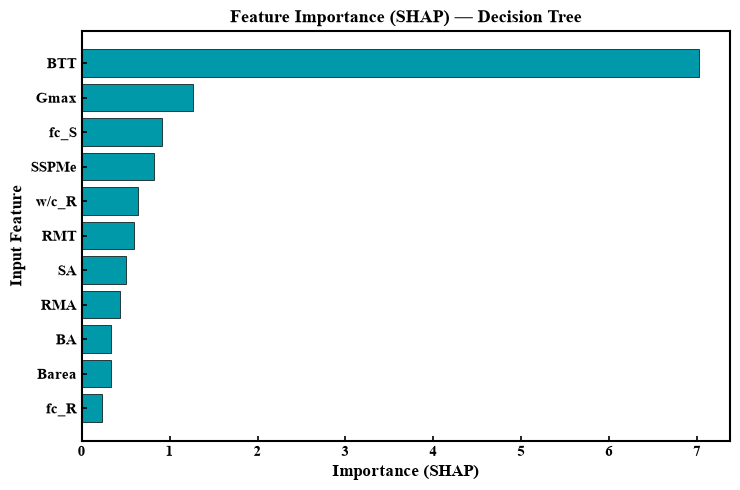

  Saved → analysis_outputs\FI_bar_RF.png


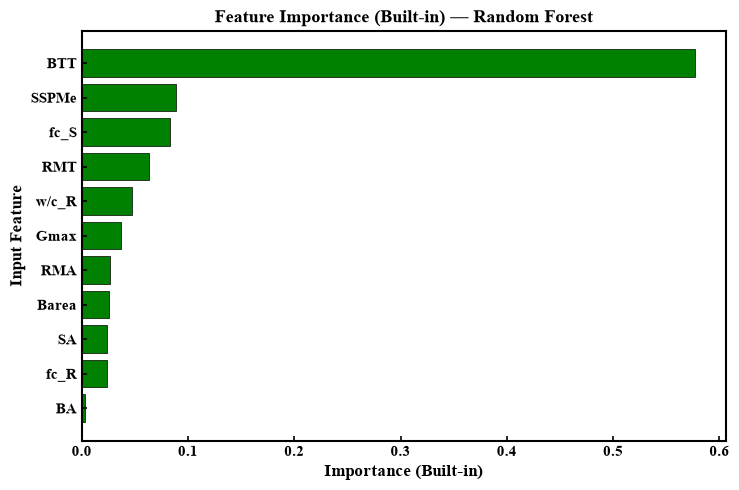

  Saved → analysis_outputs\PI_bar_RF.png


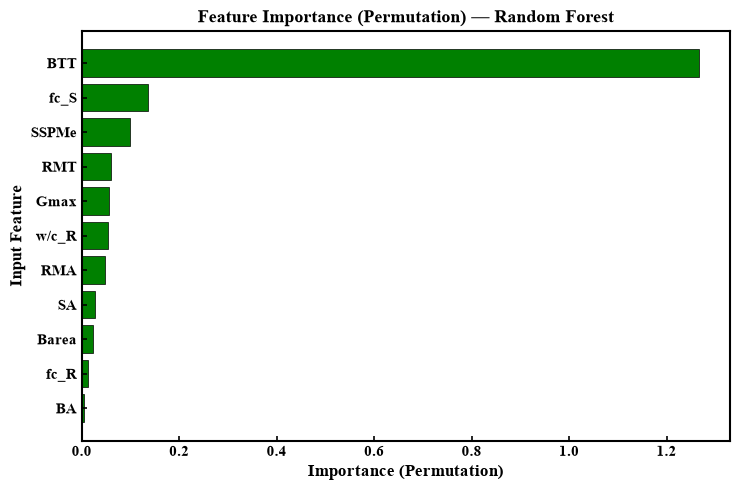

  Saved → analysis_outputs\SHAP_bar_RF.png


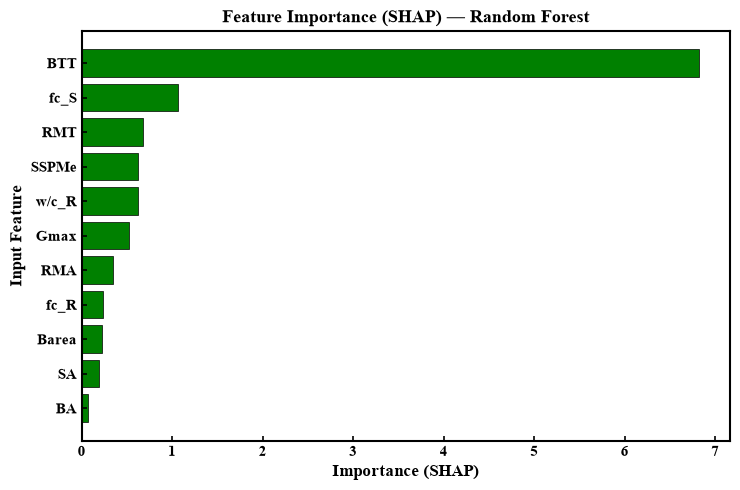

  Saved → analysis_outputs\FI_bar_XGB.png


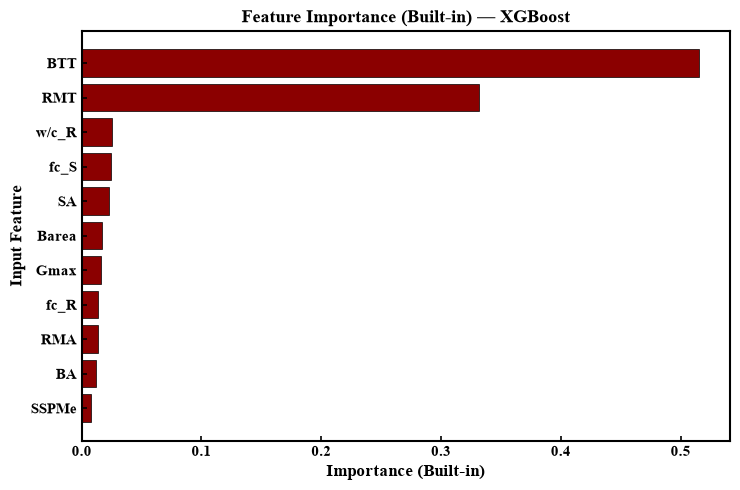

  Saved → analysis_outputs\PI_bar_XGB.png


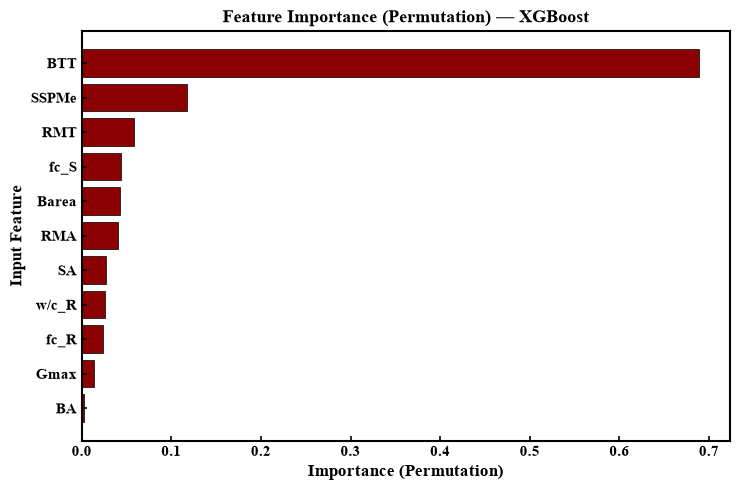

  Saved → analysis_outputs\SHAP_bar_XGB.png


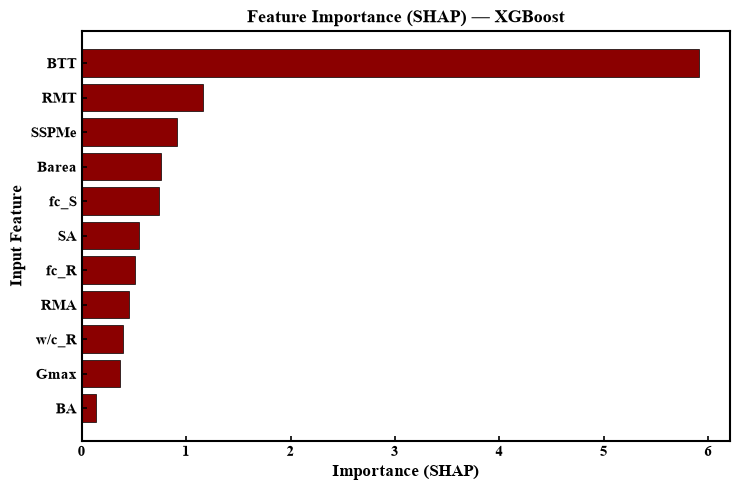

  Saved → analysis_outputs\SHAP_beeswarm_CatBoost.png


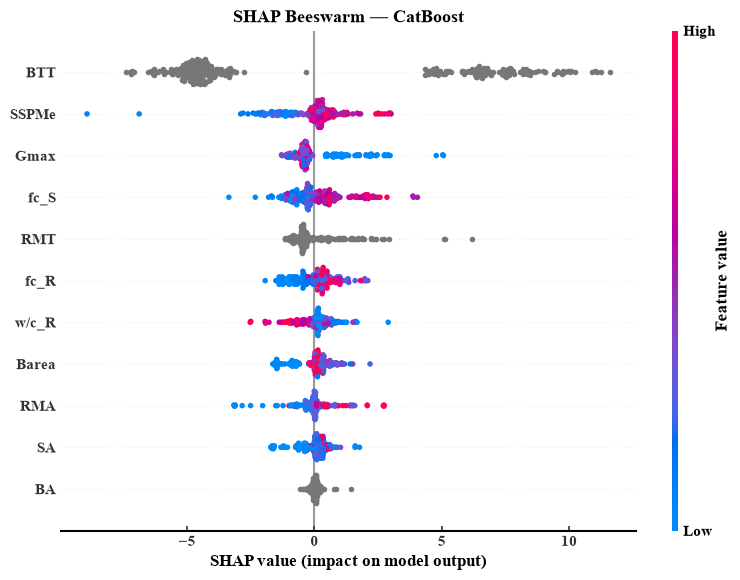

  Saved → analysis_outputs\SHAP_beeswarm_DT.png


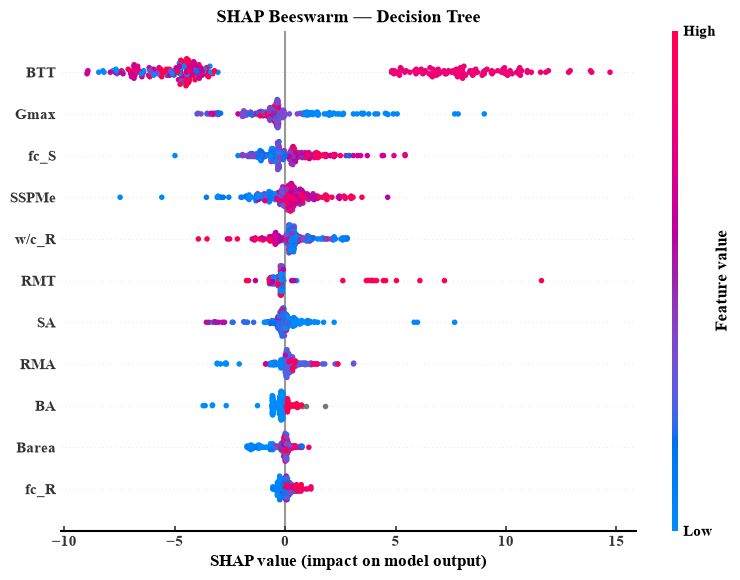

  Saved → analysis_outputs\SHAP_beeswarm_RF.png


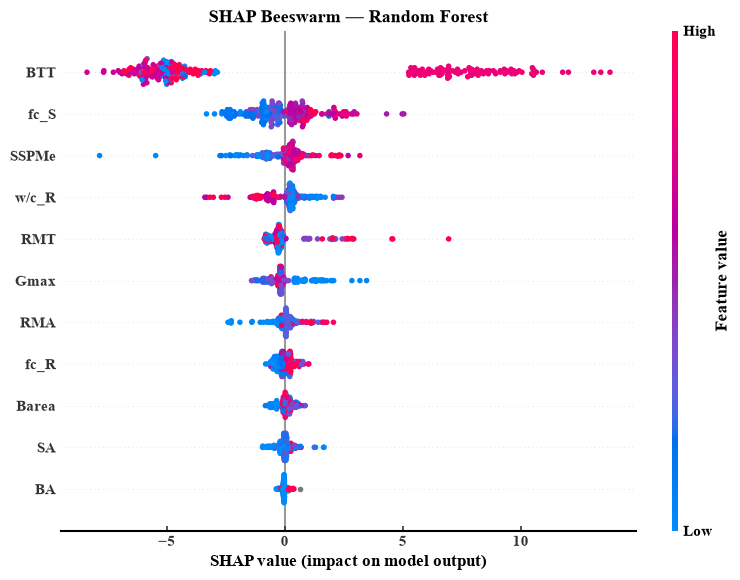

  Saved → analysis_outputs\SHAP_beeswarm_XGB.png


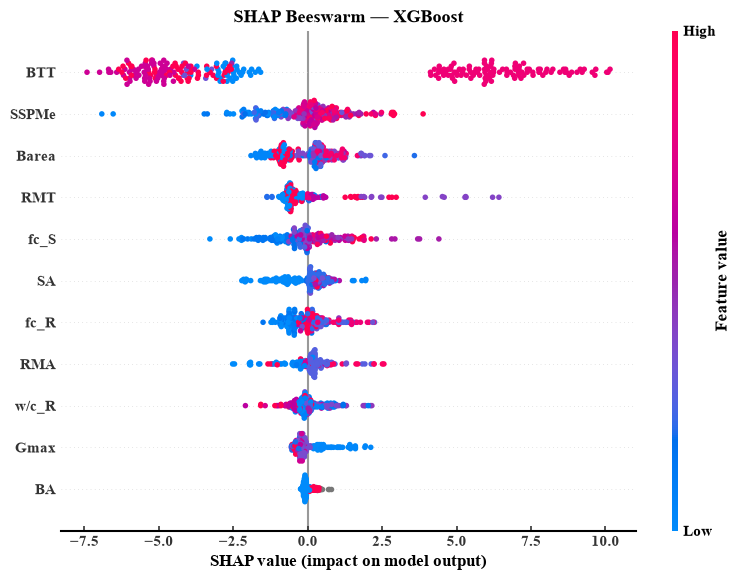

In [33]:
# ============================================================

# SECTION 19: FEATURE IMPORTANCE (Built-in, Permutation, SHAP)
# ============================================================
#
#  Computes three importance types for all four models,
#  saves raw CSVs, then plots each individually.
#
#  Note: CatBoost exposes feature_importances_ on the raw
#  feature space (X); DT / RF / XGB on the encoded space
#  (X_enc).  Separate feature-name lists are maintained.
# ────────────────────────────────────────────────────────────

# ── 19A: Feature name lists ───────────────────────────────────
FEATURES_RAW = list(X.columns)           # for CatBoost
FEATURES_ENC = list(X_train_enc.columns) # for DT / RF / XGB

# ── 19B: Built-in importances ────────────────────────────────
fi_cat  = pd.Series(best_cat.feature_importances_,  index=FEATURES_RAW)
fi_dt   = pd.Series(best_dt.feature_importances_,   index=FEATURES_ENC)
fi_rf   = pd.Series(best_rf.feature_importances_,   index=FEATURES_ENC)
fi_xgb  = pd.Series(best_xgb.feature_importances_,  index=FEATURES_ENC)

fi_cat.to_csv(os.path.join(OUT, "FI_builtin_CatBoost.csv"))
fi_dt.to_csv(os.path.join(OUT,  "FI_builtin_DT.csv"))
fi_rf.to_csv(os.path.join(OUT,  "FI_builtin_RF.csv"))
fi_xgb.to_csv(os.path.join(OUT, "FI_builtin_XGB.csv"))

# ── 19C: Permutation importances ─────────────────────────────
_perm_kw = dict(n_repeats=N_REPEAT_PERM,
                random_state=RANDOM_STATE, n_jobs=-1)

perm_cat = permutation_importance(best_cat, X_test,     y_test, **_perm_kw)
perm_dt  = permutation_importance(best_dt,  X_test_enc, y_test, **_perm_kw)
perm_rf  = permutation_importance(best_rf,  X_test_enc, y_test, **_perm_kw)
perm_xgb = permutation_importance(best_xgb, X_test_enc, y_test, **_perm_kw)

pi_cat  = pd.Series(perm_cat.importances_mean,  index=FEATURES_RAW)
pi_dt   = pd.Series(perm_dt.importances_mean,   index=FEATURES_ENC)
pi_rf   = pd.Series(perm_rf.importances_mean,   index=FEATURES_ENC)
pi_xgb  = pd.Series(perm_xgb.importances_mean,  index=FEATURES_ENC)

pi_cat.to_csv(os.path.join(OUT,  "PI_CatBoost.csv"))
pi_dt.to_csv(os.path.join(OUT,   "PI_DT.csv"))
pi_rf.to_csv(os.path.join(OUT,   "PI_RF.csv"))
pi_xgb.to_csv(os.path.join(OUT,  "PI_XGB.csv"))

# ── 19D: SHAP importances ─────────────────────────────────────
shap.initjs()

exp_cat  = shap.TreeExplainer(best_cat)
sv_cat   = exp_cat.shap_values(X_test)
shap_cat = pd.Series(np.abs(sv_cat).mean(0), index=FEATURES_RAW)

exp_dt   = shap.TreeExplainer(best_dt)
sv_dt    = exp_dt.shap_values(X_test_enc)
shap_dt  = pd.Series(np.abs(sv_dt).mean(0),  index=FEATURES_ENC)

exp_rf   = shap.TreeExplainer(best_rf)
sv_rf    = exp_rf.shap_values(X_test_enc)
shap_rf  = pd.Series(np.abs(sv_rf).mean(0),  index=FEATURES_ENC)

exp_xgb  = shap.TreeExplainer(best_xgb)
sv_xgb   = exp_xgb.shap_values(X_test_enc)
shap_xgb = pd.Series(np.abs(sv_xgb).mean(0), index=FEATURES_ENC)

shap_cat.to_csv(os.path.join(OUT, "SHAP_CatBoost.csv"))
shap_dt.to_csv(os.path.join(OUT,  "SHAP_DT.csv"))
shap_rf.to_csv(os.path.join(OUT,  "SHAP_RF.csv"))
shap_xgb.to_csv(os.path.join(OUT, "SHAP_XGB.csv"))

print("  Feature importance CSVs saved.")

# ── 19E: Individual importance bar plots ──────────────────────
#
#  OHE dummies (e.g. BTT_push, BTT_pull, RMT_wet) are collapsed
#  back to their parent raw column (BTT, RMT) before plotting so
#  every bar represents one original input variable, not one
#  encoding category.

def _collapse_to_raw(series, raw_features):
    """Sum OHE dummy columns back into their parent raw feature."""
    out = {}
    for raw in raw_features:
        if raw in series.index:
            out[raw] = series[raw]
        else:
            mask = series.index.str.startswith(raw + "_")
            out[raw] = series[mask].sum() if mask.any() else 0.0
    return pd.Series(out, index=raw_features)


def plot_feat_importance_bar(importance, title, x_label,
                             color, save_path=None):
    """
    Horizontal bar chart of feature importances.
    `importance` must already be indexed by RAW feature names.
    Sorted ascending so the most important feature sits at top.
    """
    imp_sorted = importance.sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(7.5, max(5, len(imp_sorted) * 0.42)))
    ax.barh(imp_sorted.index, imp_sorted.values,
            color=color, edgecolor="black", linewidth=0.5)

    _style_ax(ax, title, xlabel=x_label, ylabel="Input Feature")
    plt.tight_layout()
    _save_show(fig, save_path)


# CatBoost — already on raw feature space, no collapse needed
for _imp, _method, _slug in [
    (fi_cat,   "Built-in",    "FI"),
    (pi_cat,   "Permutation", "PI"),
    (shap_cat, "SHAP",        "SHAP"),
]:
    plot_feat_importance_bar(
        importance = _imp,
        title      = f"Feature Importance ({_method}) — CatBoost",
        x_label    = f"Importance ({_method})",
        color      = "#1b3f7a",
        save_path  = os.path.join(OUT, f"{_slug}_bar_CatBoost.png"),
    )

# Decision Tree — collapse OHE dummies to raw input variables
for _imp_enc, _method, _slug in [
    (fi_dt,   "Built-in",    "FI"),
    (pi_dt,   "Permutation", "PI"),
    (shap_dt, "SHAP",        "SHAP"),
]:
    plot_feat_importance_bar(
        importance = _collapse_to_raw(_imp_enc, FEATURES_RAW),
        title      = f"Feature Importance ({_method}) — Decision Tree",
        x_label    = f"Importance ({_method})",
        color      = "#0099aa",
        save_path  = os.path.join(OUT, f"{_slug}_bar_DT.png"),
    )

# Random Forest — collapse OHE dummies to raw input variables
for _imp_enc, _method, _slug in [
    (fi_rf,   "Built-in",    "FI"),
    (pi_rf,   "Permutation", "PI"),
    (shap_rf, "SHAP",        "SHAP"),
]:
    plot_feat_importance_bar(
        importance = _collapse_to_raw(_imp_enc, FEATURES_RAW),
        title      = f"Feature Importance ({_method}) — Random Forest",
        x_label    = f"Importance ({_method})",
        color      = "green",
        save_path  = os.path.join(OUT, f"{_slug}_bar_RF.png"),
    )

# XGBoost — collapse OHE dummies to raw input variables
for _imp_enc, _method, _slug in [
    (fi_xgb,   "Built-in",    "FI"),
    (pi_xgb,   "Permutation", "PI"),
    (shap_xgb, "SHAP",        "SHAP"),
]:
    plot_feat_importance_bar(
        importance = _collapse_to_raw(_imp_enc, FEATURES_RAW),
        title      = f"Feature Importance ({_method}) — XGBoost",
        x_label    = f"Importance ({_method})",
        color      = "#8b0000",
        save_path  = os.path.join(OUT, f"{_slug}_bar_XGB.png"),
    )

# ── 19F: SHAP beeswarm plots ──────────────────────────────────
#
#  For DT / RF / XGB, SHAP values are computed on the OHE-encoded
#  space (one column per dummy).  We collapse them to the raw
#  feature space before plotting so each row = one input variable.
#
#  Collapsing strategy for beeswarm: group the OHE SHAP columns
#  by their parent feature and take the mean absolute SHAP per
#  observation across dummies, then rebuild a reduced X for display.

def _collapse_shap_to_raw(shap_values, enc_features, raw_features):
    """
    Collapse OHE SHAP value matrix (n_obs x n_enc) to raw feature
    space (n_obs x n_raw) by summing dummy columns into the parent.
    Returns (collapsed_shap_array, raw_feature_names).
    """
    import numpy as np
    collapsed = np.zeros((shap_values.shape[0], len(raw_features)))
    for j, raw in enumerate(raw_features):
        if raw in enc_features:
            idx = list(enc_features).index(raw)
            collapsed[:, j] = shap_values[:, idx]
        else:
            idxs = [i for i, c in enumerate(enc_features)
                    if c.startswith(raw + "_")]
            if idxs:
                # Sum signed contributions of all dummies for this variable
                collapsed[:, j] = shap_values[:, idxs].sum(axis=1)
    return collapsed, list(raw_features)


def _collapse_X_to_raw(X_enc, raw_features):
    """
    Build a display DataFrame aligned to raw features.
    OHE dummies are represented by a single numeric column
    (argmax of dummies, i.e. the chosen category index).
    """
    out = {}
    for raw in raw_features:
        if raw in X_enc.columns:
            out[raw] = X_enc[raw].values.astype(float)
        else:
            dummy_cols = [c for c in X_enc.columns if c.startswith(raw + "_")]
            if dummy_cols:
                # Convert one-hot back to a category integer
                out[raw] = X_enc[dummy_cols].values.argmax(axis=1).astype(float)
            else:
                out[raw] = np.zeros(len(X_enc))
    return pd.DataFrame(out)


def plot_shap_beeswarm(shap_values, X_data, feature_names,
                       title, save_path=None,
                       raw_features=None, enc_features=None):
    """
    SHAP summary (beeswarm) with journal-consistent styling.
    When raw_features and enc_features are both supplied, OHE
    dummies are collapsed back to raw input variables before plotting.
    """
    if raw_features is not None and enc_features is not None:
        sv_plot, fn_plot = _collapse_shap_to_raw(
            shap_values, enc_features, raw_features)
        X_plot = _collapse_X_to_raw(X_data, raw_features)
    else:
        sv_plot  = shap_values
        fn_plot  = feature_names
        X_plot   = X_data

    fig = plt.figure(figsize=(8, 6))
    shap.summary_plot(sv_plot, X_plot, feature_names=fn_plot, show=False)
    ax = plt.gca()
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("SHAP value (impact on model output)",
                  fontsize=12, fontweight="bold")
    ax.tick_params(axis="both", labelsize=11)
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontweight("bold")
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
    plt.tight_layout()
    _save_show(fig, save_path)


# CatBoost — raw space already, no collapse needed
plot_shap_beeswarm(
    sv_cat, X_test, FEATURES_RAW,
    title     = "SHAP Beeswarm — CatBoost",
    save_path = os.path.join(OUT, "SHAP_beeswarm_CatBoost.png"),
)

# Decision Tree — collapse OHE to raw
plot_shap_beeswarm(
    sv_dt, X_test_enc, FEATURES_ENC,
    title        = "SHAP Beeswarm — Decision Tree",
    save_path    = os.path.join(OUT, "SHAP_beeswarm_DT.png"),
    raw_features = FEATURES_RAW,
    enc_features = FEATURES_ENC,
)

# Random Forest — collapse OHE to raw
plot_shap_beeswarm(
    sv_rf, X_test_enc, FEATURES_ENC,
    title        = "SHAP Beeswarm — Random Forest",
    save_path    = os.path.join(OUT, "SHAP_beeswarm_RF.png"),
    raw_features = FEATURES_RAW,
    enc_features = FEATURES_ENC,
)

# XGBoost — collapse OHE to raw
plot_shap_beeswarm(
    sv_xgb, X_test_enc, FEATURES_ENC,
    title        = "SHAP Beeswarm — XGBoost",
    save_path    = os.path.join(OUT, "SHAP_beeswarm_XGB.png"),
    raw_features = FEATURES_RAW,
    enc_features = FEATURES_ENC,
)



── Aggregation Weights (proportional to R²) ────────────
  CAT_Builtin        0.0857
  CAT_Perm           0.0857
  CAT_SHAP           0.0857
  DT_Builtin         0.0802
  DT_Perm            0.0802
  DT_SHAP            0.0802
  RF_Builtin         0.0849
  RF_Perm            0.0849
  RF_SHAP            0.0849
  XGB_Builtin        0.0826
  XGB_Perm           0.0826
  XGB_SHAP           0.0826
  Saved → analysis_outputs\Aggregated_FI_stacked.png


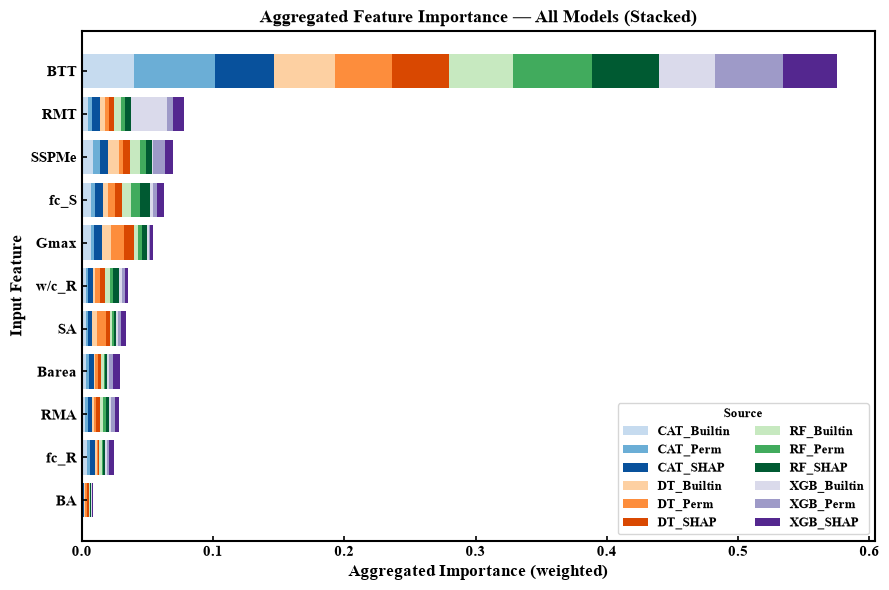

  Saved → analysis_outputs\Degree_of_Influence.png


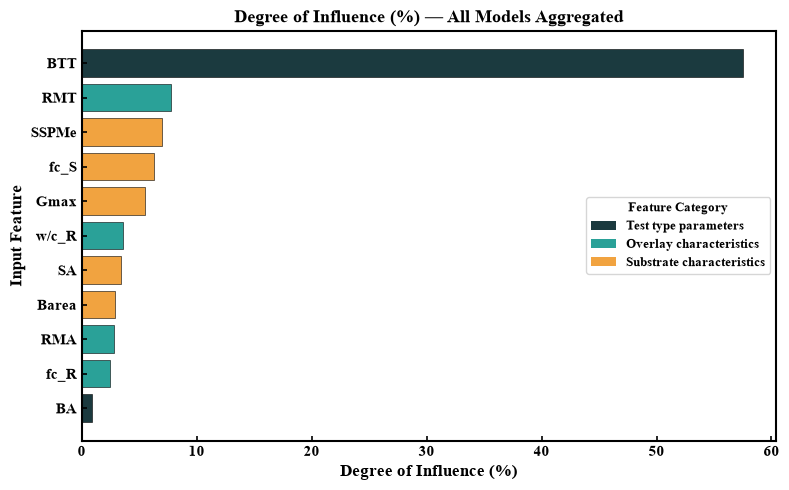

  Saved → analysis_outputs\Category_Contribution_Pie.png


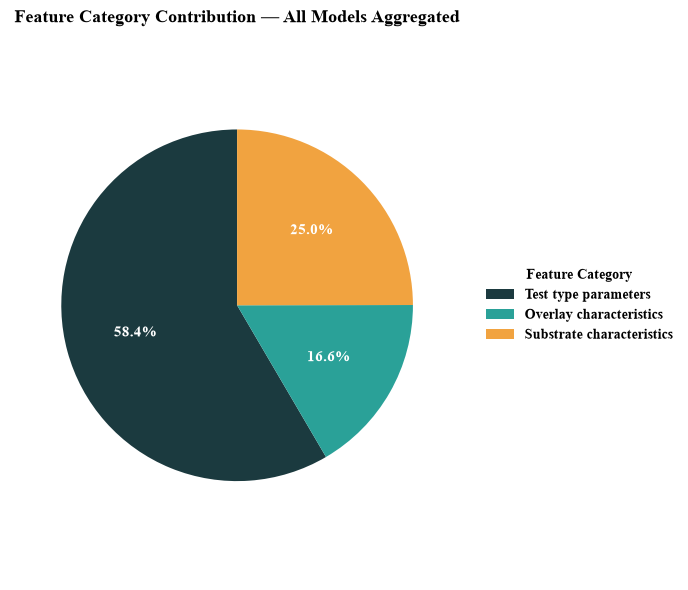


  PIPELINE COMPLETE — all outputs saved to: analysis_outputs


In [35]:
# ============================================================
# SECTION 20: AGGREGATED FEATURE IMPORTANCE
# ============================================================
#
#  Strategy (mirrors the 4-step approach in the reference):
#
#  Step 1 — Normalise each importance series so all methods
#            are on a common [0,1] scale (Eq. 4).
#
#  Step 2 — Assign model weights proportional to each model's
#            test-set R² (Eq. 5).  Models that predict better
#            contribute more to the aggregate.
#
#  Step 3 — Weight and sum normalised importances across all
#            models and methods to produce a single aggregated
#            importance score per feature (Eq. 6).
#
#  Step 4 — Visualise:
#            (a) stacked horizontal bar  (per-source breakdown)
#            (b) degree-of-influence %   (bar, colour-coded by
#                feature category)
#            (c) category-contribution   (pie chart)
#
#  Note: CatBoost operates on the raw feature space; DT / RF /
#  XGB operate on the OHE-encoded space.  To aggregate across
#  all four models on a COMMON feature basis, OHE dummies are
#  collapsed back to their parent categorical column by summing.
# ────────────────────────────────────────────────────────────

# ── 20A: Collapse OHE columns back to raw feature names ───────

def _collapse_ohe(series, raw_features):
    """
    Given an importance Series with OHE column names, return a
    new Series aligned to raw_features by summing all OHE dummies
    that start with '<raw_col>_' into a single entry.
    """
    out = {}
    for raw in raw_features:
        # Exact match first
        if raw in series.index:
            out[raw] = series[raw]
        else:
            # Sum all OHE dummies that belong to this raw column
            mask = series.index.str.startswith(raw + "_")
            out[raw] = series[mask].sum() if mask.any() else 0.0
    return pd.Series(out, index=raw_features)


# Collapse encoded importances to the raw feature space
fi_dt_c    = _collapse_ohe(fi_dt,   FEATURES_RAW)
fi_rf_c    = _collapse_ohe(fi_rf,   FEATURES_RAW)
fi_xgb_c   = _collapse_ohe(fi_xgb,  FEATURES_RAW)

pi_dt_c    = _collapse_ohe(pi_dt,   FEATURES_RAW)
pi_rf_c    = _collapse_ohe(pi_rf,   FEATURES_RAW)
pi_xgb_c   = _collapse_ohe(pi_xgb,  FEATURES_RAW)

shap_dt_c  = _collapse_ohe(shap_dt,  FEATURES_RAW)
shap_rf_c  = _collapse_ohe(shap_rf,  FEATURES_RAW)
shap_xgb_c = _collapse_ohe(shap_xgb, FEATURES_RAW)

# ── 20B: Step 1 — Normalise each series (Eq. 4) ───────────────

def _norm(s):
    total = s.sum()
    return s / total if total > 0 else s * 0.0


norm = {
    "CAT_Builtin":  _norm(fi_cat),
    "CAT_Perm":     _norm(pi_cat),
    "CAT_SHAP":     _norm(shap_cat),
    "DT_Builtin":   _norm(fi_dt_c),
    "DT_Perm":      _norm(pi_dt_c),
    "DT_SHAP":      _norm(shap_dt_c),
    "RF_Builtin":   _norm(fi_rf_c),
    "RF_Perm":      _norm(pi_rf_c),
    "RF_SHAP":      _norm(shap_rf_c),
    "XGB_Builtin":  _norm(fi_xgb_c),
    "XGB_Perm":     _norm(pi_xgb_c),
    "XGB_SHAP":     _norm(shap_xgb_c),
}

# ── 20C: Step 2 — Model weights from test R² (Eq. 5) ──────────
#  Each of the three methods per model inherits the same model R².

_r2_map = {
    "CAT_Builtin":  r2_cat,  "CAT_Perm":  r2_cat,  "CAT_SHAP":  r2_cat,
    "DT_Builtin":   r2_dt,   "DT_Perm":   r2_dt,   "DT_SHAP":   r2_dt,
    "RF_Builtin":   r2_rf,   "RF_Perm":   r2_rf,   "RF_SHAP":   r2_rf,
    "XGB_Builtin":  r2_xgb,  "XGB_Perm":  r2_xgb,  "XGB_SHAP":  r2_xgb,
}

# Clip negative R² to zero so a poor model doesn't subtract weight
_r2_map = {k: max(v, 0.0) for k, v in _r2_map.items()}
_total_r2 = sum(_r2_map.values())

weights = {k: v / _total_r2 for k, v in _r2_map.items()}

print("\n── Aggregation Weights (proportional to R²) ────────────")
for _k, _w in weights.items():
    print(f"  {_k:<18} {_w:.4f}")

# ── 20D: Step 3 — Weighted aggregate (Eq. 6) ─────────────────

FI_agg = pd.Series(0.0, index=FEATURES_RAW)
for key in norm:
    FI_agg += weights[key] * norm[key]

FI_agg.to_csv(os.path.join(OUT, "Aggregated_FI_all_models.csv"))

# ── 20E: Step 4a — Stacked bar (source breakdown) ────────────

# Build weighted-contribution DataFrame
contrib = pd.DataFrame(
    {k: weights[k] * norm[k] for k in norm},
    index=FEATURES_RAW,
)
contrib["Aggregated"] = contrib.sum(axis=1)
contrib = contrib.sort_values("Aggregated", ascending=True)
contrib.to_csv(os.path.join(OUT, "Aggregated_FI_stacked.csv"))

# Colour scheme: two shades per model family
_STACK_COLORS = {
    "CAT_Builtin":  "#c6dbef",
    "CAT_Perm":     "#6baed6",
    "CAT_SHAP":     "#08519c",
    "DT_Builtin":   "#fdd0a2",
    "DT_Perm":      "#fd8d3c",
    "DT_SHAP":      "#d94801",
    "RF_Builtin":   "#c7e9c0",
    "RF_Perm":      "#41ab5d",
    "RF_SHAP":      "#005a32",
    "XGB_Builtin":  "#dadaeb",
    "XGB_Perm":     "#9e9ac8",
    "XGB_SHAP":     "#54278f",
}

_STACK_COLS = list(_STACK_COLORS.keys())

fig, ax = plt.subplots(figsize=(9, max(6, len(contrib) * 0.4)))
left = np.zeros(len(contrib))

for col in _STACK_COLS:
    ax.barh(contrib.index, contrib[col].values,
            left=left, color=_STACK_COLORS[col],
            label=col, edgecolor="none")
    left += contrib[col].values

_style_ax(ax,
          title   = "Aggregated Feature Importance — All Models (Stacked)",
          xlabel  = "Aggregated Importance (weighted)",
          ylabel  = "Input Feature")

ax.legend(title="Source", loc="lower right",
          fontsize=9, title_fontsize=9,
          ncol=2, frameon=True)
plt.tight_layout()
_save_show(fig, os.path.join(OUT, "Aggregated_FI_stacked.png"))

# ── 20F: Step 4b — Degree-of-influence % (category colours) ──

# ▸ Edit this map to match your actual feature names
CATEGORY_MAP = {
    "BTT":   "Test type parameters",
    "BA":    "Test type parameters",
    "RMA":   "Overlay characteristics",
    "RCA":   "Overlay characteristics",
    "w/c_R": "Overlay characteristics",
    "fc_R":  "Overlay characteristics",
    "RMT":   "Overlay characteristics",
    "RCC":   "Overlay characteristics",
    "fc_S":  "Substrate characteristics",
    "w/c_S": "Substrate characteristics",
    "SCA":   "Substrate characteristics",
    "Gmax":  "Substrate characteristics",
    "SA":    "Substrate characteristics",
    "SSMC":  "Substrate characteristics",
    "Barea":   "Substrate characteristics",
    # Monte-Carlo derived features
    "CSP_sampled":    "Substrate characteristics",
    "SSPMe": "Substrate characteristics",
}

_CAT_COLORS = {
    "Test type parameters":     "#1b3a3f",
    "Overlay characteristics":  "#2aa198",
    "Substrate characteristics":"#f1a340",
}

degree_pct = 100.0 * FI_agg / FI_agg.sum()
plot_df = pd.DataFrame({
    "Feature":   degree_pct.index,
    "Influence": degree_pct.values,
    "Category":  [CATEGORY_MAP.get(f, "Other") for f in degree_pct.index],
})
plot_df = plot_df.sort_values("Influence", ascending=False)

fig, ax = plt.subplots(figsize=(8, max(5, len(plot_df) * 0.40)))
bar_colors = plot_df["Category"].map(_CAT_COLORS).fillna("#888888")
ax.barh(plot_df["Feature"], plot_df["Influence"],
        color=bar_colors, edgecolor="black", linewidth=0.4)
ax.invert_yaxis()   # largest bar at the top

_style_ax(ax,
          title  = "Degree of Influence (%) — All Models Aggregated",
          xlabel = "Degree of Influence (%)",
          ylabel = "Input Feature")

legend_patches = [
    Patch(facecolor=_CAT_COLORS[k], label=k)
    for k in _CAT_COLORS
]
ax.legend(handles=legend_patches, title="Feature Category",
          loc="center right", frameon=True,
          fontsize=9, title_fontsize=9)

plt.tight_layout()
_save_show(fig, os.path.join(OUT, "Degree_of_Influence.png"))

# ── 20G: Step 4c — Category-contribution pie chart ───────────

cat_contrib = (
    plot_df.groupby("Category")["Influence"]
    .sum()
    .reindex(list(_CAT_COLORS.keys()))
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(7, 6))
wedges, texts, autotexts = ax.pie(
    cat_contrib.values,
    colors     = list(_CAT_COLORS.values()),
    startangle = 90,
    autopct    = "%1.1f%%",
    textprops  = {"fontsize": 11, "fontweight": "bold", "color": "white"},
)
ax.axis("equal")

legend_patches = [
    Patch(facecolor=_CAT_COLORS[k], label=k)
    for k in _CAT_COLORS
]
ax.legend(handles=legend_patches, title="Feature Category",
          loc="center left", bbox_to_anchor=(1.02, 0.5),
          frameon=False, fontsize=10, title_fontsize=10)

ax.set_title("Feature Category Contribution — All Models Aggregated",
             fontsize=13, fontweight="bold")

plt.tight_layout()
_save_show(fig, os.path.join(OUT, "Category_Contribution_Pie.png"))


# ============================================================
print("\n" + "=" * 58)
print("  PIPELINE COMPLETE — all outputs saved to:", OUT)
print("=" * 58)